<a href="https://colab.research.google.com/github/rajanaids-hub/BASICS-ML/blob/main/Ex1_Data_PreProcessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Complete Data Preprocessing: Beginner to Advanced

**For B.Tech AI & DS Students**

---

## 1. Introduction & Why Preprocessing Matters

Data preprocessing is a crucial step in the machine learning workflow. Without clean and well-prepared data, even the most sophisticated models can perform poorly. As the saying goes in the ML world: **"Garbage In, Garbage Out (GIGO)"**.

### Why is it so important?

1.  **Improved Model Performance**: Clean and properly formatted data directly leads to better model accuracy, robustness, and generalization. Messy data can introduce noise, bias, and hinder the learning process.
2.  **Reduced Training Time**: Well-preprocessed data can accelerate the training process by eliminating irrelevant features, handling outliers, and scaling features appropriately.
3.  **Enhanced Interpretability**: Consistent data makes it easier to understand model behavior and identify important features.
4.  **Consistency Across Environments**: In a production setting (2026 industry standard), consistent data pipelines ensure that models behave predictably, whether in development, testing, or deployment.
5.  **Business Impact**: Accurate predictions and insights derived from clean data lead to better business decisions, improved efficiency, and competitive advantage. In 2026, data scientists spend a significant portion of their time (often 60-80%) on data preparation, highlighting its critical role.

## 2. Loading Data & Initial Exploration

The first step in any data science project is to load your data and get a preliminary understanding of its structure and content. We'll primarily use the `pandas` library for this, which is the cornerstone for data manipulation in Python.

In [ ]:
import pandas as pd
import numpy as np

# Let's create a synthetic dataset for demonstration purposes.
# In a real-world scenario, you would load data from a CSV, database, etc.

# --- Creating a Synthetic Dataset ---
np.random.seed(42) # for reproducibility

data = {
    'CustomerID': np.arange(101, 121),
    'Age': np.random.randint(18, 70, 20),
    'Gender': np.random.choice(['Male', 'Female', 'Other'], 20, p=[0.45, 0.5, 0.05]),
    'ProductCategory': np.random.choice(['Electronics', 'Clothing', 'Books', 'Groceries'], 20),
    'MonthlySpend': np.random.uniform(50, 1000, 20).round(2),
    'EnrollmentDate': pd.to_datetime(pd.date_range(start='2022-01-01', periods=20, freq='M')),
    'Rating': np.random.randint(1, 6, 20),
    'Region': np.random.choice(['North', 'South', 'East', 'West', np.nan], 20, p=[0.2, 0.2, 0.2, 0.2, 0.2]), # Introducing NaNs
    'Income': np.random.normal(50000, 15000, 20).round(2),
    'IsPrimeMember': np.random.choice([True, False], 20, p=[0.3, 0.7])
}

df = pd.DataFrame(data)

# Introduce some more missing values artificially for demonstration
df.loc[[1, 5, 12], 'Age'] = np.nan
df.loc[[3, 8], 'MonthlySpend'] = np.nan
df.loc[[0, 10], 'Gender'] = np.nan

print("Synthetic DataFrame created successfully!")

Synthetic DataFrame created successfully!


/tmp/ipykernel_9526/825316218.py:16: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  'EnrollmentDate': pd.to_datetime(pd.date_range(start='2022-01-01', periods=20, freq='M')),


### Basic Data Exploration Commands

Once the data is loaded, we use several `pandas` methods to get a quick overview. These are essential for understanding the dataset's shape, data types, and initial statistical summaries.

In [ ]:
# Display the first 5 rows of the DataFrame
# This gives a quick peek at the data and column names.
print("\n--- First 5 rows of the DataFrame ---")
display(df.head())

# Display the last 5 rows of the DataFrame
print("\n--- Last 5 rows of the DataFrame ---")
display(df.tail())

# Display a concise summary of the DataFrame
# This includes the index dtype and column dtypes, non-null values, and memory usage.
# Crucial for identifying missing values and incorrect data types.
print("\n--- DataFrame Info ---")
df.info()

# Generate descriptive statistics of numerical columns
# Provides count, mean, standard deviation, min, max, and quartiles.
# Useful for understanding the distribution and potential outliers of numerical features.
print("\n--- Descriptive Statistics for Numerical Columns ---")
display(df.describe())

# Generate descriptive statistics for all columns (including categorical)
# By including 'object' for categorical and 'all' for everything.
print("\n--- Descriptive Statistics for All Columns ---")
display(df.describe(include='all'))

# Get the shape of the DataFrame (rows, columns)
print(f"\n--- DataFrame Shape --- \nRows: {df.shape[0]}, Columns: {df.shape[1]}")

# Get the column names
print("\n--- Column Names ---")
print(df.columns.tolist())


--- First 5 rows of the DataFrame ---


,CustomerID,Age,Gender,ProductCategory,MonthlySpend,EnrollmentDate,Rating,Region,Income,IsPrimeMember
0,101,56.0,NaN,Books,82.67,2022-01-31,5,West,10703.82,True
1,102,NaN,Male,Clothing,913.85,2022-02-28,2,North,62328.54,False
2,103,46.0,Male,Groceries,295.84,2022-03-31,1,South,51305.71,False
3,104,32.0,Male,Electronics,NaN,2022-04-30,4,North,45514.89,False
4,105,60.0,Male,Groceries,346.13,2022-05-31,4,nan,51376.41,True



--- Last 5 rows of the DataFrame ---


,CustomerID,Age,Gender,ProductCategory,MonthlySpend,EnrollmentDate,Rating,Region,Income,IsPrimeMember
15,116,41.0,Female,Groceries,236.18,2023-04-30,3,West,57699.01,False
16,117,20.0,Female,Books,92.97,2023-05-31,3,West,51456.16,False
17,118,39.0,Male,Groceries,359.06,2023-06-30,1,East,64529.67,True
18,119,19.0,Female,Electronics,419.24,2023-07-31,3,West,39469.20,False
19,120,41.0,Male,Groceries,307.78,2023-08-31,3,East,45085.07,False



--- DataFrame Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   CustomerID       20 non-null     int64         
 1   Age              17 non-null     float64       
 2   Gender           18 non-null     object        
 3   ProductCategory  20 non-null     object        
 4   MonthlySpend     18 non-null     float64       
 5   EnrollmentDate   20 non-null     datetime64[ns]
 6   Rating           20 non-null     int64         
 7   Region           20 non-null     object        
 8   Income           20 non-null     float64       
 9   IsPrimeMember    20 non-null     bool          
dtypes: bool(1), datetime64[ns](1), float64(3), int64(2), object(3)
memory usage: 1.6+ KB

--- Descriptive Statistics for Numerical Columns ---


,CustomerID,Age,MonthlySpend,EnrollmentDate,Rating,Income
count,20.00000,17.000000,18.000000,20,20.000000,20.000000
mean,110.50000,40.588235,483.311111,2022-11-14 12:00:00,2.850000,47858.653000
min,101.00000,19.000000,82.670000,2022-01-31 00:00:00,1.000000,10703.820000
25%,105.75000,32.000000,251.095000,2022-06-22 12:00:00,1.000000,42182.862500
50%,110.50000,40.000000,389.150000,2022-11-15 00:00:00,3.000000,49005.315000
75%,115.25000,53.000000,744.285000,2023-04-07 12:00:00,4.000000,55942.270000
max,120.00000,60.000000,942.520000,2023-08-31 00:00:00,5.000000,72168.410000
std,5.91608,12.786999,302.291200,NaN,1.598519,14501.811108



--- Descriptive Statistics for All Columns ---


,CustomerID,Age,Gender,ProductCategory,MonthlySpend,EnrollmentDate,Rating,Region,Income,IsPrimeMember
count,20.00000,17.000000,18,20,18.000000,20,20.000000,20,20.000000,20
unique,NaN,NaN,2,4,NaN,NaN,NaN,5,NaN,2
top,NaN,NaN,Male,Groceries,NaN,NaN,NaN,West,NaN,False
freq,NaN,NaN,11,7,NaN,NaN,NaN,7,NaN,15
mean,110.50000,40.588235,NaN,NaN,483.311111,2022-11-14 12:00:00,2.850000,NaN,47858.653000,NaN
min,101.00000,19.000000,NaN,NaN,82.670000,2022-01-31 00:00:00,1.000000,NaN,10703.820000,NaN
25%,105.75000,32.000000,NaN,NaN,251.095000,2022-06-22 12:00:00,1.000000,NaN,42182.862500,NaN
50%,110.50000,40.000000,NaN,NaN,389.150000,2022-11-15 00:00:00,3.000000,NaN,49005.315000,NaN
75%,115.25000,53.000000,NaN,NaN,744.285000,2023-04-07 12:00:00,4.000000,NaN,55942.270000,NaN
max,120.00000,60.000000,NaN,NaN,942.520000,2023-08-31 00:00:00,5.000000,NaN,72168.410000,NaN



--- DataFrame Shape --- 
Rows: 20, Columns: 10

--- Column Names ---
['CustomerID', 'Age', 'Gender', 'ProductCategory', 'MonthlySpend', 'EnrollmentDate', 'Rating', 'Region', 'Income', 'IsPrimeMember']


### <div style="text-align: center;">--- End of Section 2 ---</div>

Next, we will dive into **Deep Exploratory Data Analysis (EDA)** to uncover more insights and prepare for specific preprocessing steps.

## 3. Deep EDA (Exploratory Data Analysis)

Deep EDA is where we really start to understand the underlying patterns, distributions, and relationships within our data. This step is crucial for making informed decisions about data preprocessing and feature engineering. We'll cover:

*   Univariate Analysis (single variable distributions)
*   Bivariate Analysis (relationships between two variables)
*   Multivariate Analysis (relationships among three or more variables)
*   Correlation Analysis
*   Missing Value Analysis
*   Interactive Plots (using Plotly)

### 3.1 Understanding Data Types and Unique Values

Before diving into distributions, it's good practice to understand the nature of our features: which are categorical, numerical, or temporal, and how many unique values each has. This helps in deciding appropriate visualization and preprocessing techniques.

In [ ]:
print("\n--- Unique Values per Column ---")
for col in df.columns:
    if df[col].dtype == 'object' or df[col].dtype == 'bool': # Categorical or boolean
        print(f"Column '{col}': {df[col].nunique()} unique values - {df[col].unique()}")
    else:
        print(f"Column '{col}': {df[col].nunique()} unique values")

# Also check the number of unique values more generally
print("\n--- Number of Unique Values for All Columns ---")
display(pd.DataFrame(df.nunique(), columns=['Number of Unique Values']))


--- Unique Values per Column ---
Column 'CustomerID': 20 unique values
Column 'Age': 14 unique values
Column 'Gender': 2 unique values - [nan 'Male' 'Female']
Column 'ProductCategory': 4 unique values - ['Books' 'Clothing' 'Groceries' 'Electronics']
Column 'MonthlySpend': 18 unique values
Column 'EnrollmentDate': 20 unique values
Column 'Rating': 5 unique values
Column 'Region': 5 unique values - ['West' 'North' 'South' 'nan' 'East']
Column 'Income': 20 unique values
Column 'IsPrimeMember': 2 unique values - [ True False]

--- Number of Unique Values for All Columns ---


,Number of Unique Values
CustomerID,20
Age,14
Gender,2
ProductCategory,4
MonthlySpend,18
EnrollmentDate,20
Rating,5
Region,5
Income,20
IsPrimeMember,2


### 3.2 Missing Value Analysis

Missing values are a common problem in real-world datasets. They can occur for various reasons (data entry errors, data corruption, privacy concerns, etc.) and can significantly impact model performance. It's vital to identify, quantify, and understand the pattern of missing data before deciding on a treatment strategy.

First, let's quantify the missing values.

In [ ]:
# Calculate the total number of missing values per column
missing_values = df.isnull().sum()

# Calculate the percentage of missing values per column
missing_percentage = (df.isnull().sum() / len(df)) * 100

# Create a DataFrame to display missing values information
missing_info = pd.DataFrame({
    'Missing Values': missing_values,
    'Missing Percentage (%)': missing_percentage
})

# Filter to show only columns with missing values and sort them
missing_info = missing_info[missing_info['Missing Values'] > 0].sort_values(by='Missing Percentage (%)', ascending=False)

print("\n--- Missing Value Information ---")
display(missing_info)

if missing_info.empty:
    print("No missing values found in the dataset.")
else:
    print("\nColumns with missing values are listed above. We will address these in Section 4.")


--- Missing Value Information ---


,Missing Values,Missing Percentage (%)
Age,3,15.0
Gender,2,10.0
MonthlySpend,2,10.0



Columns with missing values are listed above. We will address these in Section 4.


### 3.3 Visualizing Missing Values

Visualizing missing values can help us understand their distribution and patterns. The `missingno` library is excellent for this, but we can also use other plotting libraries.

First, ensure `missingno` is installed. If not, the following cell will install it.


--- Visualizing Missing Data (Matrix Plot) ---


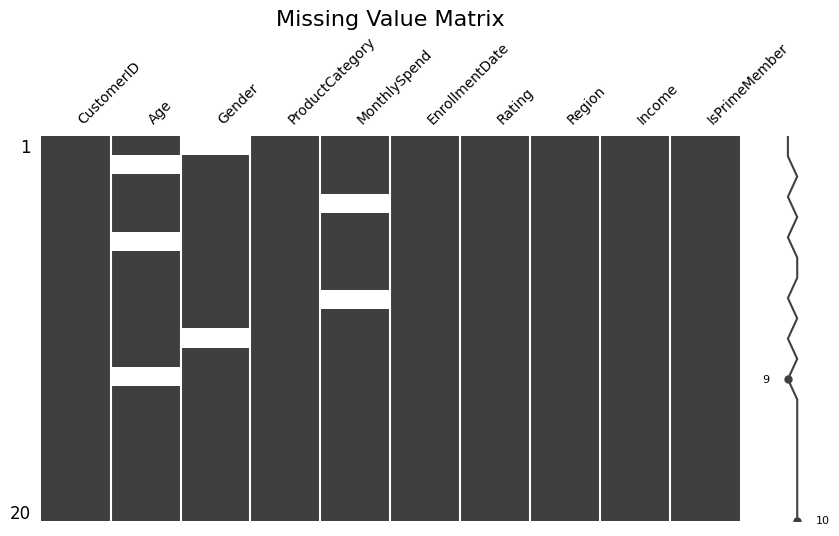


--- Visualizing Missing Data (Bar Plot) ---


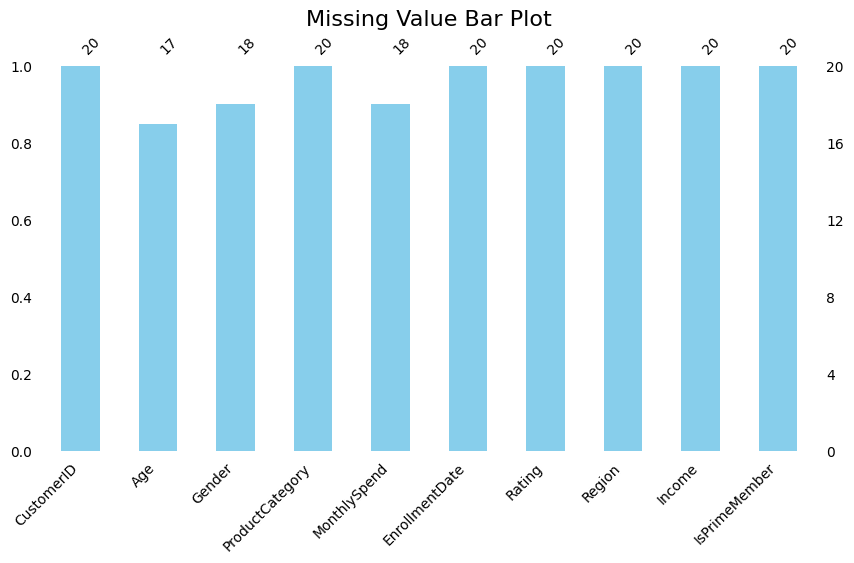


--- Visualizing Missing Data (Heatmap) ---


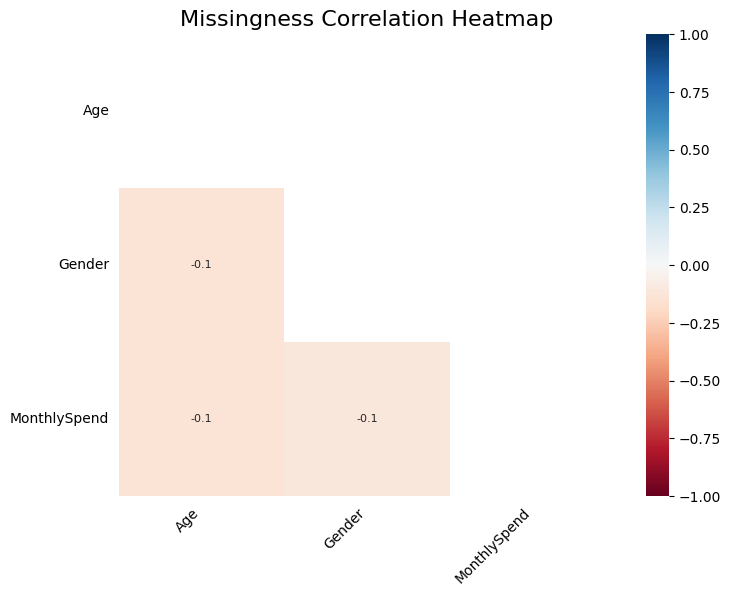

In [ ]:
# Install missingno if not already installed
try:
    import missingno as msno
except ImportError:
    print("Installing missingno...")
    !pip install missingno
    import missingno as msno

import matplotlib.pyplot as plt

print("\n--- Visualizing Missing Data (Matrix Plot) ---")
# The matrix plot visualizes the presence of missing values
# Each row represents a data entry, and each column represents a feature.
# A white line indicates a missing value.
msno.matrix(df, figsize=(10, 5), fontsize=10)
plt.title('Missing Value Matrix', fontsize=16)
plt.show()

print("\n--- Visualizing Missing Data (Bar Plot) ---")
# The bar plot shows the count of non-null values for each column.
msno.bar(df, figsize=(10, 5), fontsize=10, color='skyblue')
plt.title('Missing Value Bar Plot', fontsize=16)
plt.show()

print("\n--- Visualizing Missing Data (Heatmap) ---")
# The heatmap shows the correlation of missingness between different variables.
# A value close to 1 means that if one variable is missing, the other is likely to be missing too.
# A value close to 0 means missingness is uncorrelated.
msno.heatmap(df, figsize=(8, 6), fontsize=10)
plt.title('Missingness Correlation Heatmap', fontsize=16)
plt.show()

### 3.4 Univariate Analysis: Distributions of Individual Features

Univariate analysis involves examining each feature independently. This helps us understand the central tendency, spread, and shape of the data distribution, which is crucial for identifying outliers, skewness, and the need for transformations.

In [ ]:
import plotly.express as px

print("\n--- Univariate Analysis: Numerical Features ---")
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

for col in numerical_cols:
    if col != 'CustomerID': # CustomerID is an identifier, not a feature for distribution analysis
        # Histogram for distribution
        fig = px.histogram(df, x=col, title=f'Distribution of {col}', marginal='box', nbins=30)
        fig.update_layout(height=400, width=600)
        fig.show()

print("\n--- Univariate Analysis: Categorical Features ---")
categorical_cols = df.select_dtypes(include='object').columns.tolist()

for col in categorical_cols:
    # Get value counts and reset index to create a DataFrame for plotting
    counts_df = df[col].value_counts().reset_index()
    # Rename columns for clarity in Plotly Express
    counts_df.columns = ['category', 'count']

    fig = px.bar(counts_df,
                 x='category', y='count', title=f'Count of {col}')
    fig.update_layout(xaxis_title=col, yaxis_title='Count', height=400, width=600)
    fig.show()


--- Univariate Analysis: Numerical Features ---



--- Univariate Analysis: Categorical Features ---


### 3.5 Bivariate Analysis: Relationships Between Two Features

Bivariate analysis explores the relationships between two variables at a time. This helps us understand how features interact with each other and how they might influence the target variable (if we had one). Common techniques include scatter plots (numerical vs. numerical), box plots (numerical vs. categorical), and stacked bar charts (categorical vs. categorical).

In [ ]:
print("\n--- Bivariate Analysis: Numerical vs. Numerical (Scatter Plots) ---")

# Example 1: Age vs. MonthlySpend
fig = px.scatter(df, x='Age', y='MonthlySpend', color='Gender',
                 title='Age vs. Monthly Spend (Colored by Gender)',
                 hover_data=['CustomerID', 'ProductCategory'])
fig.update_layout(height=500, width=800)
fig.show()

# Example 2: Income vs. MonthlySpend
fig = px.scatter(df, x='Income', y='MonthlySpend', color='IsPrimeMember',
                 title='Income vs. Monthly Spend (Colored by Prime Membership)',
                 hover_data=['CustomerID', 'ProductCategory'])
fig.update_layout(height=500, width=800)
fig.show()

print("\n--- Bivariate Analysis: Numerical vs. Categorical (Box Plots) ---")

# Example 1: MonthlySpend by ProductCategory
fig = px.box(df, x='ProductCategory', y='MonthlySpend', color='ProductCategory',
             title='Monthly Spend by Product Category')
fig.update_layout(height=500, width=800)
fig.show()

# Example 2: Age by Gender
fig = px.box(df, x='Gender', y='Age', color='Gender',
             title='Age Distribution by Gender')
fig.update_layout(height=500, width=800)
fig.show()

print("\n--- Bivariate Analysis: Categorical vs. Categorical (Stacked Bar Charts) ---")

# Example: Product Category distribution by Region
df_grouped = df.groupby(['Region', 'ProductCategory']).size().reset_index(name='Count')
fig = px.bar(df_grouped, x='Region', y='Count', color='ProductCategory',
             title='Product Category Distribution by Region', barmode='stack')
fig.update_layout(height=500, width=800)
fig.show()


--- Bivariate Analysis: Numerical vs. Numerical (Scatter Plots) ---



--- Bivariate Analysis: Numerical vs. Categorical (Box Plots) ---



--- Bivariate Analysis: Categorical vs. Categorical (Stacked Bar Charts) ---


### 3.6 Multivariate Analysis

Multivariate analysis involves examining the relationships among three or more variables simultaneously. This can reveal more complex patterns that might not be visible in univariate or bivariate analyses. While visualising more than two or three dimensions directly can be challenging, techniques like `pairplot` from `seaborn` (though it can be slow for many features) or using color/size in Plotly scatter plots can help.


--- Multivariate Analysis: Pair Plot (Numerical Features) ---


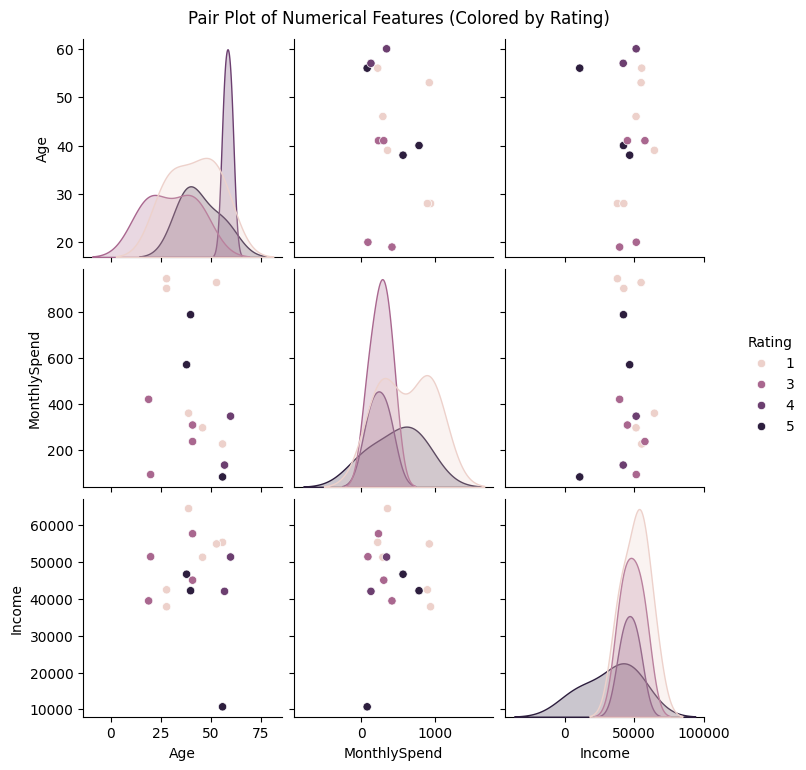


--- Multivariate Analysis with Plotly: 3D Scatter Plot ---


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

print("\n--- Multivariate Analysis: Pair Plot (Numerical Features) ---")
# Pair plots visualize relationships between all pairs of numerical features.
# Note: This can be computationally intensive for large datasets or many numerical features.

numerical_features_for_pairplot = ['Age', 'MonthlySpend', 'Income', 'Rating']

sns.pairplot(df[numerical_features_for_pairplot].dropna(), hue='Rating', diag_kind='kde')
plt.suptitle('Pair Plot of Numerical Features (Colored by Rating)', y=1.02) # Adjust title position
plt.show()

print("\n--- Multivariate Analysis with Plotly: 3D Scatter Plot ---")
# Example: Age, MonthlySpend, Income with Gender as color
fig = px.scatter_3d(df.dropna(subset=['Age', 'MonthlySpend', 'Income', 'Gender']),
                    x='Age', y='MonthlySpend', z='Income', color='Gender',
                    title='3D Scatter: Age, Monthly Spend, Income by Gender')
fig.update_layout(height=600, width=900)
fig.show()

### 3.7 Correlation Analysis

Correlation measures the statistical relationship between two variables. For numerical features, Pearson correlation is common. It ranges from -1 (perfect negative correlation) to +1 (perfect positive correlation), with 0 indicating no linear correlation. Understanding correlations helps in identifying redundant features, potential multicollinearity, and features strongly related to the target.

For categorical features, other measures like Cramer's V or Chi-squared test are used, but for simplicity, we'll focus on numerical correlations first.


--- Correlation Matrix (Numerical Features) ---


,CustomerID,Age,MonthlySpend,Rating,Income
CustomerID,1.00,-0.41,-0.12,-0.25,0.25
Age,-0.41,1.00,-0.27,0.09,-0.07
MonthlySpend,-0.12,-0.27,1.00,-0.33,0.14
Rating,-0.25,0.09,-0.33,1.00,-0.36
Income,0.25,-0.07,0.14,-0.36,1.00


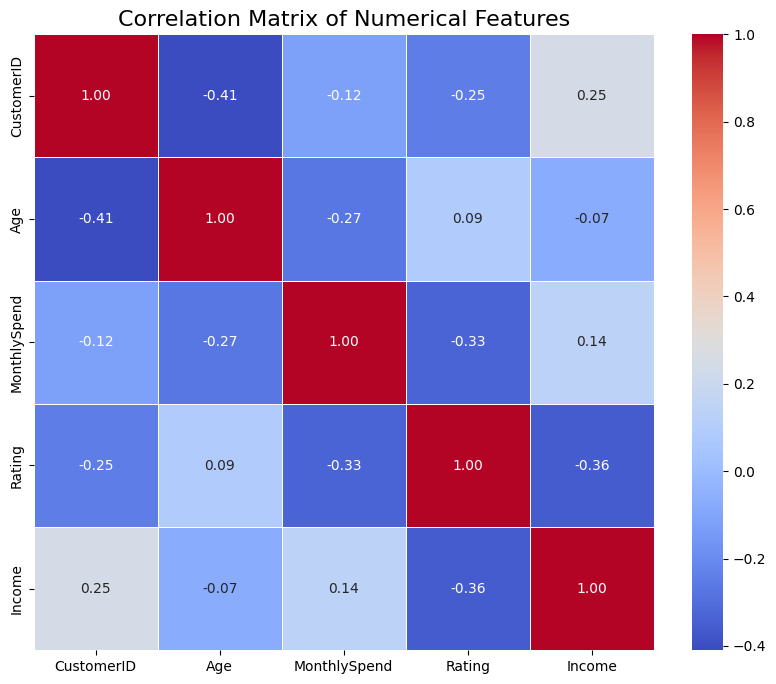


--- Correlation with a Specific Feature (e.g., MonthlySpend) ---
MonthlySpend    1.000000
Income          0.140210
CustomerID     -0.117796
Age            -0.269263
Rating         -0.327663
Name: MonthlySpend, dtype: float64


In [ ]:
print("\n--- Correlation Matrix (Numerical Features) ---")

# Select only numerical columns for correlation calculation
numerical_df = df.select_dtypes(include=np.number)

# Calculate the correlation matrix
correlation_matrix = numerical_df.corr().round(2)

# Display the correlation matrix
display(correlation_matrix)

# Visualize the correlation matrix using a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Numerical Features', fontsize=16)
plt.show()

print("\n--- Correlation with a Specific Feature (e.g., MonthlySpend) ---")
# Often, we are interested in how other features correlate with a key feature (e.g., our target variable).
correlation_with_monthly_spend = numerical_df.corr()['MonthlySpend'].sort_values(ascending=False)
print(correlation_with_monthly_spend)


### <div style="text-align: center;">--- End of Section 3 (Deep EDA) ---</div>

With a solid understanding of our data's structure, distributions, and relationships, we are now well-prepared to tackle missing values, outliers, and feature scaling in the upcoming sections.

## 4. Handling Missing Values

Missing values are a common challenge in real-world datasets. They can lead to biased models, reduced statistical power, and errors in analysis. The way we handle missing data can significantly impact the performance and reliability of our machine learning models.

### Strategies for Handling Missing Values:

1.  **Deletion**: Removing rows or columns with missing data.
2.  **Imputation**: Filling in missing values with estimated ones.
    *   **Simple Imputation**: Mean, Median, Mode imputation.
    *   **Advanced Imputation**: K-Nearest Neighbors (KNN) Imputer, Regression Imputation, etc.

The choice of strategy depends on the nature of the data, the amount of missingness, and the problem context. Always consider the potential impact of your chosen method on the data distribution and relationships.

Let's apply some of these techniques to our synthetic dataset.

In [ ]:
# Create a copy of the original DataFrame to demonstrate different imputation techniques without altering the original.
df_imputed = df.copy()

print("Original DataFrame with missing values:")
display(df_imputed[df_imputed.isnull().any(axis=1)]) # Display rows with NaNs

print("\n--- Missing values before handling ---")
display(df_imputed.isnull().sum()[df_imputed.isnull().sum() > 0])

Original DataFrame with missing values:


,CustomerID,Age,Gender,ProductCategory,MonthlySpend,EnrollmentDate,Rating,Region,Income,IsPrimeMember
0,101,56.0,NaN,Books,82.67,2022-01-31,5,West,10703.82,True
1,102,NaN,Male,Clothing,913.85,2022-02-28,2,North,62328.54,False
3,104,32.0,Male,Electronics,NaN,2022-04-30,4,North,45514.89,False
5,106,NaN,Female,Clothing,544.06,2022-06-30,4,West,20186.47,False
8,109,36.0,Female,Electronics,NaN,2022-09-30,5,South,72168.41,True
10,111,28.0,NaN,Electronics,942.52,2022-11-30,1,West,37872.60,False
12,113,NaN,Female,Groceries,618.00,2023-01-31,1,nan,63731.03,False



--- Missing values before handling ---


,0
Age,3
Gender,2
MonthlySpend,2


### 4.1 Deletion Methods

Deletion is the simplest approach, but it should be used cautiously as it can lead to loss of valuable data and introduce bias if the missingness is not random.

#### 4.1.1 Row-wise Deletion (`dropna()`)

This method removes entire rows that contain any missing values. It's often suitable when the number of rows with missing values is small, or when missingness is random and distributed across many features.

In [ ]:
df_deleted_rows = df.copy()
initial_rows = df_deleted_rows.shape[0]

df_deleted_rows.dropna(inplace=True)

rows_after_deletion = df_deleted_rows.shape[0]

print(f"Initial number of rows: {initial_rows}")
print(f"Number of rows after deleting NaNs: {rows_after_deletion}")
print(f"Number of rows deleted: {initial_rows - rows_after_deletion}")

print("\nMissing values after row-wise deletion:")
display(df_deleted_rows.isnull().sum()[df_deleted_rows.isnull().sum() > 0])

if (initial_rows - rows_after_deletion) > 0:
    print("Note: Row-wise deletion can drastically reduce dataset size.")

Initial number of rows: 20
Number of rows after deleting NaNs: 13
Number of rows deleted: 7

Missing values after row-wise deletion:


,0


Note: Row-wise deletion can drastically reduce dataset size.


#### 4.1.2 Column-wise Deletion

This method removes entire columns that contain missing values. It's usually considered when a column has a very high percentage of missing values, making it difficult to impute meaningfully, or if the column is deemed irrelevant after EDA.

In [ ]:
df_deleted_cols = df.copy()
initial_cols = df_deleted_cols.shape[1]

# Identify columns with missing values
missing_cols = df_deleted_cols.columns[df_deleted_cols.isnull().any()].tolist()

df_deleted_cols.dropna(axis=1, inplace=True)

cols_after_deletion = df_deleted_cols.shape[1]

print(f"Initial number of columns: {initial_cols}")
print(f"Columns with missing values: {missing_cols}")
print(f"Number of columns after deleting NaNs: {cols_after_deletion}")
print(f"Number of columns deleted: {initial_cols - cols_after_deletion}")

print("\nMissing values after column-wise deletion:")
display(df_deleted_cols.isnull().sum()[df_deleted_cols.isnull().sum() > 0])

if (initial_cols - cols_after_deletion) > 0:
    print("Note: Column-wise deletion might lead to loss of potentially useful features if not careful.")

Initial number of columns: 10
Columns with missing values: ['Age', 'Gender', 'MonthlySpend']
Number of columns after deleting NaNs: 7
Number of columns deleted: 3

Missing values after column-wise deletion:


,0


Note: Column-wise deletion might lead to loss of potentially useful features if not careful.


### 4.2 Simple Imputation Techniques

Simple imputation methods replace missing values with a statistical measure calculated from the non-missing values in that column. These are quick and easy to implement but can reduce variance and distort relationships if not applied carefully.

#### 4.2.1 Mean Imputation (for Numerical Features)

Replaces missing numerical values with the mean of the column. Best for data that is normally distributed and when missingness is completely at random (MCAR).

DataFrame after Mean Imputation:


/tmp/ipykernel_9526/3009187163.py:7: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.



/tmp/ipykernel_9526/3009187163.py:8: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or

,0
Gender,2



Mean Age used for imputation: 40.59
Mean Monthly Spend used for imputation: 483.31

Effect on 'Age' distribution (before vs. after):


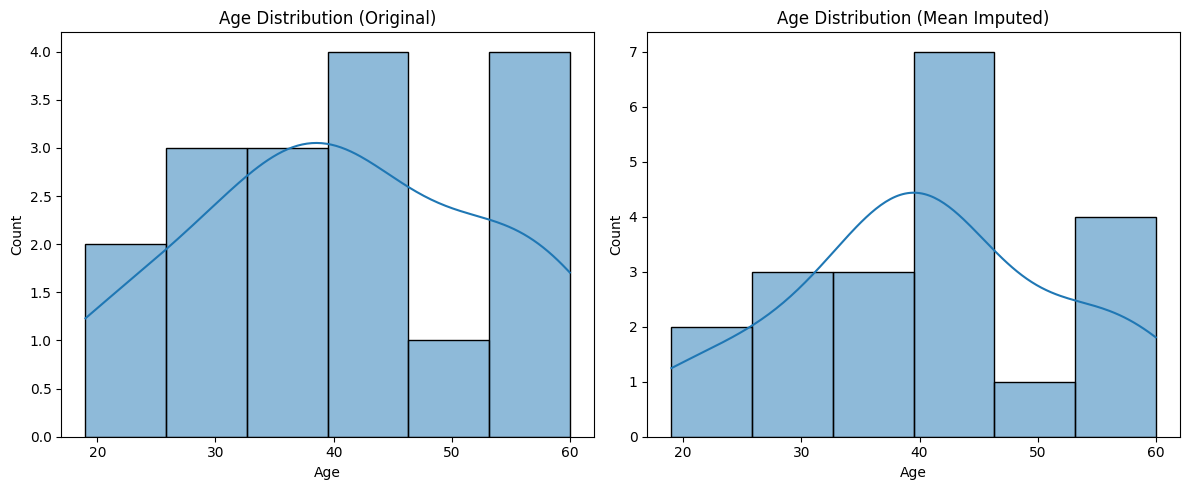

In [ ]:
df_mean_imputed = df.copy()

# Impute 'Age' and 'MonthlySpend' with their respective means
mean_age = df_mean_imputed['Age'].mean()
mean_monthly_spend = df_mean_imputed['MonthlySpend'].mean()

df_mean_imputed['Age'].fillna(mean_age, inplace=True)
df_mean_imputed['MonthlySpend'].fillna(mean_monthly_spend, inplace=True)

print("DataFrame after Mean Imputation:")
display(df_mean_imputed.isnull().sum()[df_mean_imputed.isnull().sum() > 0])

print(f"\nMean Age used for imputation: {mean_age:.2f}")
print(f"Mean Monthly Spend used for imputation: {mean_monthly_spend:.2f}")

print("\nEffect on 'Age' distribution (before vs. after):")
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df['Age'].dropna(), kde=True)
plt.title('Age Distribution (Original)')
plt.subplot(1, 2, 2)
sns.histplot(df_mean_imputed['Age'], kde=True)
plt.title('Age Distribution (Mean Imputed)')
plt.tight_layout()
plt.show()

#### 4.2.2 Median Imputation (for Numerical Features)

Replaces missing numerical values with the median of the column. More robust to outliers than mean imputation, making it suitable for skewed distributions.

DataFrame after Median Imputation:


/tmp/ipykernel_9526/798133929.py:7: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.



/tmp/ipykernel_9526/798133929.py:8: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or d

,0
Gender,2



Median Age used for imputation: 40.00
Median Monthly Spend used for imputation: 389.15

Effect on 'MonthlySpend' distribution (before vs. after):


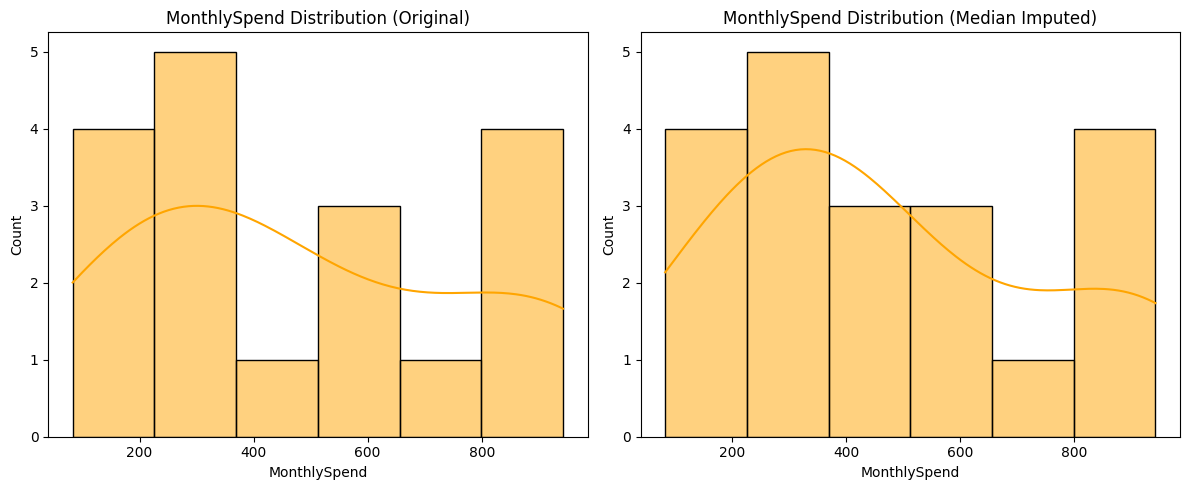

In [ ]:
df_median_imputed = df.copy()

# Impute 'Age' and 'MonthlySpend' with their respective medians
median_age = df_median_imputed['Age'].median()
median_monthly_spend = df_median_imputed['MonthlySpend'].median()

df_median_imputed['Age'].fillna(median_age, inplace=True)
df_median_imputed['MonthlySpend'].fillna(median_monthly_spend, inplace=True)

print("DataFrame after Median Imputation:")
display(df_median_imputed.isnull().sum()[df_median_imputed.isnull().sum() > 0])

print(f"\nMedian Age used for imputation: {median_age:.2f}")
print(f"Median Monthly Spend used for imputation: {median_monthly_spend:.2f}")

print("\nEffect on 'MonthlySpend' distribution (before vs. after):")
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df['MonthlySpend'].dropna(), kde=True, color='orange')
plt.title('MonthlySpend Distribution (Original)')
plt.subplot(1, 2, 2)
sns.histplot(df_median_imputed['MonthlySpend'], kde=True, color='orange')
plt.title('MonthlySpend Distribution (Median Imputed)')
plt.tight_layout()
plt.show()

#### 4.2.3 Mode Imputation (for Categorical Features)

Replaces missing categorical values with the mode (most frequent category) of the column. Can also be used for numerical features, especially for discrete values with a clear mode.

DataFrame after Mode Imputation:


/tmp/ipykernel_9526/3140941755.py:6: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.





,0
Age,3
MonthlySpend,2


/tmp/ipykernel_9526/3140941755.py:16: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipykernel_9526/3140941755.py:19: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.





Mode Gender used for imputation: 'Male'

Effect on 'Gender' distribution (before vs. after):


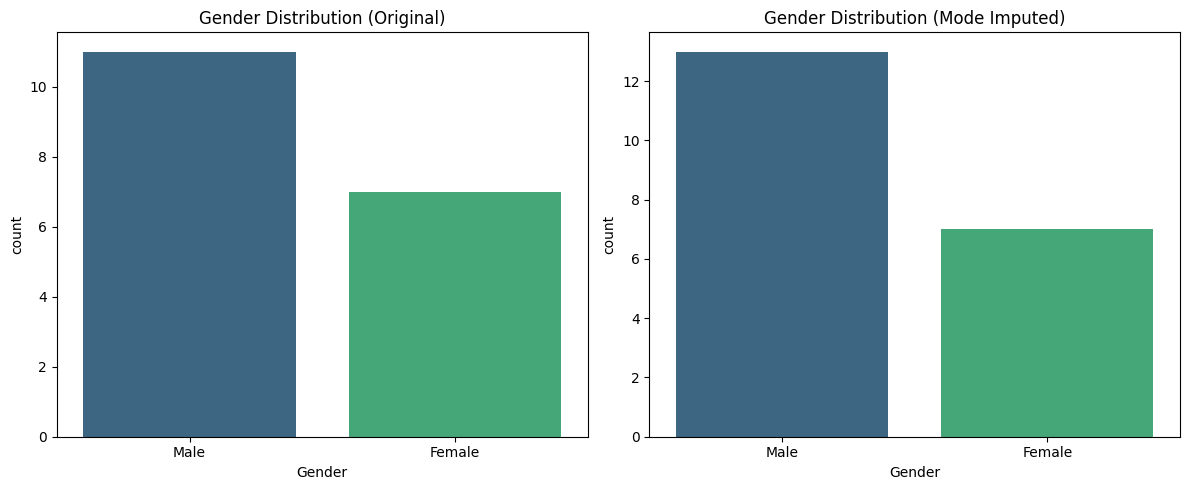

In [ ]:
df_mode_imputed = df.copy()

# Impute 'Gender' with its mode
mode_gender = df_mode_imputed['Gender'].mode()[0] # .mode() can return multiple modes, take the first

df_mode_imputed['Gender'].fillna(mode_gender, inplace=True)

print("DataFrame after Mode Imputation:")
display(df_mode_imputed.isnull().sum()[df_mode_imputed.isnull().sum() > 0])

print(f"\nMode Gender used for imputation: '{mode_gender}'")

print("\nEffect on 'Gender' distribution (before vs. after):")
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.countplot(x=df['Gender'], palette='viridis')
plt.title('Gender Distribution (Original)')
plt.subplot(1, 2, 2)
sns.countplot(x=df_mode_imputed['Gender'], palette='viridis')
plt.title('Gender Distribution (Mode Imputed)')
plt.tight_layout()
plt.show()

### 4.3 Advanced Imputation Techniques

Simple imputation can sometimes distort relationships between variables. Advanced techniques leverage the relationships between features to make more informed imputations.

#### 4.3.1 KNNImputer (K-Nearest Neighbors Imputation)

`KNNImputer` uses the K-Nearest Neighbors algorithm to impute missing values. It finds the `n_neighbors` closest samples to the one with missing values and then imputes the missing value based on the average (for numerical) or most frequent (for categorical, though typically used for numerical) value of these neighbors. This approach preserves the relationships between features better than simple imputation.

**Note**: KNNImputer from `sklearn.impute` works on numerical data. For categorical features, we often convert them to numerical (e.g., using One-Hot Encoding) before applying KNNImputer, or use specialized methods for categorical imputation.

In [ ]:
from sklearn.impute import KNNImputer

df_knn_imputed = df.copy()

# For KNN Imputer, we need all columns to be numerical.
# Let's temporarily encode 'Gender' to numerical for this demonstration.
# In a real pipeline, this would be handled within a ColumnTransformer.

# First, let's fill the 'Region' NaN with a placeholder or mode for now,
# as it's a string 'nan' and would interfere with direct numerical conversion.
df_knn_imputed['Region'].fillna('Unknown', inplace=True)

# Convert Gender to numerical using one-hot encoding for demonstration
df_knn_imputed = pd.get_dummies(df_knn_imputed, columns=['Gender', 'ProductCategory', 'Region', 'IsPrimeMember'], drop_first=True)

# Drop CustomerID and EnrollmentDate as they are not suitable for KNN imputation directly
df_knn_imputed_numeric = df_knn_imputed.drop(columns=['CustomerID', 'EnrollmentDate'])

print("DataFrame head before KNN Imputation (with numerical representation):")
display(df_knn_imputed_numeric.head())
print("\nMissing values before KNN Imputation:")
display(df_knn_imputed_numeric.isnull().sum()[df_knn_imputed_numeric.isnull().sum() > 0])

# Initialize KNNImputer
# n_neighbors specifies the number of neighboring samples to use for imputation.
# weights='uniform' means all points in a neighborhood are weighted equally.
# weights='distance' means closer neighbors have a greater influence.
knn_imputer = KNNImputer(n_neighbors=3)

# Apply KNN imputation
# The output of fit_transform is a numpy array, so convert back to DataFrame
df_knn_imputed_array = knn_imputer.fit_transform(df_knn_imputed_numeric)
df_knn_imputed_numeric_final = pd.DataFrame(df_knn_imputed_array, columns=df_knn_imputed_numeric.columns)

print("\nDataFrame head after KNN Imputation:")
display(df_knn_imputed_numeric_final.head())
print("\nMissing values after KNN Imputation:")
display(df_knn_imputed_numeric_final.isnull().sum()[df_knn_imputed_numeric_final.isnull().sum() > 0])

print("\nNote: The 'Age' and 'MonthlySpend' columns, which had missing values, are now imputed.")

DataFrame head before KNN Imputation (with numerical representation):


/tmp/ipykernel_9526/1256697941.py:11: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.





,Age,MonthlySpend,Rating,Income,Gender_Male,ProductCategory_Clothing,ProductCategory_Electronics,ProductCategory_Groceries,Region_North,Region_South,Region_West,Region_nan,IsPrimeMember_True
0,56.0,82.67,5,10703.82,False,False,False,False,False,False,True,False,True
1,NaN,913.85,2,62328.54,True,True,False,False,True,False,False,False,False
2,46.0,295.84,1,51305.71,True,False,False,True,False,True,False,False,False
3,32.0,NaN,4,45514.89,True,False,True,False,True,False,False,False,False
4,60.0,346.13,4,51376.41,True,False,False,True,False,False,False,True,True



Missing values before KNN Imputation:


,0
Age,3
MonthlySpend,2



DataFrame head after KNN Imputation:


,Age,MonthlySpend,Rating,Income,Gender_Male,ProductCategory_Clothing,ProductCategory_Electronics,ProductCategory_Groceries,Region_North,Region_South,Region_West,Region_nan,IsPrimeMember_True
0,56.000000,82.670000,5.0,10703.82,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
1,45.333333,913.850000,2.0,62328.54,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,46.000000,295.840000,1.0,51305.71,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
3,32.000000,592.413333,4.0,45514.89,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
4,60.000000,346.130000,4.0,51376.41,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0



Missing values after KNN Imputation:


,0



Note: The 'Age' and 'MonthlySpend' columns, which had missing values, are now imputed.


#### 4.3.2 Iterative Imputer (MICE - Multiple Imputation by Chained Equations)

`IterativeImputer` (also known as MICE) is a more sophisticated imputation technique. It models each feature with missing values as a function of other features, and uses that estimate for imputation. It performs multiple imputation rounds (iterations) where each missing value is imputed using the predicted value from a regression model trained on other features. This is generally more robust than simple methods and even KNNImputer, especially when data is not MCAR.

**Note**: `IterativeImputer` is in the `experimental` module of scikit-learn, meaning its API might change in future versions. It also requires all data to be numerical.

In [ ]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.linear_model import BayesianRidge

df_iterative_imputed = df.copy()

# Prepare data for IterativeImputer (all numerical, no CustomerID/EnrollmentDate)
# We'll use the same one-hot encoded and 'Region' filled DataFrame as for KNN for consistency

df_iterative_imputed['Region'].fillna('Unknown', inplace=True)
df_iterative_imputed = pd.get_dummies(df_iterative_imputed, columns=['Gender', 'ProductCategory', 'Region', 'IsPrimeMember'], drop_first=True)

df_iterative_imputed_numeric = df_iterative_imputed.drop(columns=['CustomerID', 'EnrollmentDate'])

print("DataFrame head before Iterative Imputation (with numerical representation):")
display(df_iterative_imputed_numeric.head())
print("\nMissing values before Iterative Imputation:")
display(df_iterative_imputed_numeric.isnull().sum()[df_iterative_imputed_numeric.isnull().sum() > 0])

# Initialize IterativeImputer
# estimator can be any regressor (e.g., BayesianRidge, RandomForestRegressor, ExtraTreesRegressor)
# max_iter is the number of imputation rounds
iterative_imputer = IterativeImputer(estimator=BayesianRidge(), max_iter=10, random_state=42)

# Apply iterative imputation
df_iterative_imputed_array = iterative_imputer.fit_transform(df_iterative_imputed_numeric)
df_iterative_imputed_numeric_final = pd.DataFrame(df_iterative_imputed_array, columns=df_iterative_imputed_numeric.columns)

print("\nDataFrame head after Iterative Imputation:")
display(df_iterative_imputed_numeric_final.head())
print("\nMissing values after Iterative Imputation:")
display(df_iterative_imputed_numeric_final.isnull().sum()[df_iterative_imputed_numeric_final.isnull().sum() > 0])

print("\nNote: Iterative Imputer has filled the missing values based on relationships with other features.")

DataFrame head before Iterative Imputation (with numerical representation):


/tmp/ipykernel_9526/3338101514.py:10: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.





,Age,MonthlySpend,Rating,Income,Gender_Male,ProductCategory_Clothing,ProductCategory_Electronics,ProductCategory_Groceries,Region_North,Region_South,Region_West,Region_nan,IsPrimeMember_True
0,56.0,82.67,5,10703.82,False,False,False,False,False,False,True,False,True
1,NaN,913.85,2,62328.54,True,True,False,False,True,False,False,False,False
2,46.0,295.84,1,51305.71,True,False,False,True,False,True,False,False,False
3,32.0,NaN,4,45514.89,True,False,True,False,True,False,False,False,False
4,60.0,346.13,4,51376.41,True,False,False,True,False,False,False,True,True



Missing values before Iterative Imputation:


,0
Age,3
MonthlySpend,2



DataFrame head after Iterative Imputation:


,Age,MonthlySpend,Rating,Income,Gender_Male,ProductCategory_Clothing,ProductCategory_Electronics,ProductCategory_Groceries,Region_North,Region_South,Region_West,Region_nan,IsPrimeMember_True
0,56.00000,82.670000,5.0,10703.82,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
1,39.54505,913.850000,2.0,62328.54,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,46.00000,295.840000,1.0,51305.71,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
3,32.00000,482.391777,4.0,45514.89,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
4,60.00000,346.130000,4.0,51376.41,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0



Missing values after Iterative Imputation:


,0



Note: Iterative Imputer has filled the missing values based on relationships with other features.


### <div style="text-align: center;">--- End of Section 4 (Handling Missing Values) ---</div>

We've covered various techniques for handling missing data, from simple deletion to advanced imputation. The next step is to tackle **Outlier Detection & Treatment** to ensure our data is robust and clean for model training.

## 5. Outlier Detection & Treatment

Outliers are data points that significantly deviate from other observations. They can be due to measurement errors, data entry errors, or simply represent rare but legitimate extreme values. Outliers can skew statistical analyses and negatively impact the performance of machine learning models. Therefore, identifying and appropriately treating them is an important preprocessing step.

### Impact of Outliers:

*   **Statistical Measures**: Outliers can distort measures like mean and standard deviation.
*   **Model Training**: Can lead to biased or overfitted models, especially for algorithms sensitive to extreme values (e.g., linear regression, K-Means).

### Strategies for Handling Outliers:

1.  **Deletion**: Removing the outlier data points (rows).
2.  **Transformation**: Applying mathematical transformations (e.g., log, square root) to reduce the impact of extreme values.
3.  **Capping/Winsorization**: Replacing outliers with a specified percentile value.
4.  **Imputation**: Treating outliers as missing values and imputing them.

We will focus on detection methods first, and then briefly discuss treatment options.

In [ ]:
# For outlier detection, we'll use our original DataFrame (df) but ensure numerical columns are clean for methods that require it.
# Let's re-impute 'Age' and 'MonthlySpend' with median for this section's demonstration to have cleaner data for outlier detection.
# For categorical columns with NaNs, we'll temporarily fill them for certain visualizations if needed, or exclude them.

df_for_outliers = df.copy()

# Impute numerical missing values with median for a stable base
df_for_outliers['Age'].fillna(df_for_outliers['Age'].median(), inplace=True)
df_for_outliers['MonthlySpend'].fillna(df_for_outliers['MonthlySpend'].median(), inplace=True)

# For categorical columns, we can fill with mode or 'Unknown' for now if they participate in a visualization/method
df_for_outliers['Gender'].fillna(df_for_outliers['Gender'].mode()[0], inplace=True)
df_for_outliers['Region'].fillna('Unknown', inplace=True) # Assuming 'nan' from synthetic data is a specific category here

print("DataFrame prepared for Outlier Analysis (numerical NaNs imputed with median, categorical with mode/Unknown).")
print("Missing values check:")
display(df_for_outliers.isnull().sum()[df_for_outliers.isnull().sum() > 0])

DataFrame prepared for Outlier Analysis (numerical NaNs imputed with median, categorical with mode/Unknown).
Missing values check:


/tmp/ipykernel_9526/635199971.py:8: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.



/tmp/ipykernel_9526/635199971.py:9: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or d

,0


### 5.1 IQR Method (Interquartile Range)

The IQR method is a robust statistical approach to identify outliers, particularly useful for skewed distributions. It defines an outlier as a data point that falls below Q1 - 1.5 * IQR or above Q3 + 1.5 * IQR, where Q1 is the 25th percentile, Q3 is the 75th percentile, and IQR = Q3 - Q1.

In [ ]:
print("\n--- Outlier Detection using IQR Method ---")

numerical_cols = ['Age', 'MonthlySpend', 'Income'] # Focus on these for demonstration

for col in numerical_cols:
    Q1 = df_for_outliers[col].quantile(0.25)
    Q3 = df_for_outliers[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df_for_outliers[(df_for_outliers[col] < lower_bound) | (df_for_outliers[col] > upper_bound)]

    print(f"\nColumn: {col}")
    print(f"  Q1: {Q1:.2f}, Q3: {Q3:.2f}, IQR: {IQR:.2f}")
    print(f"  Lower Bound: {lower_bound:.2f}, Upper Bound: {upper_bound:.2f}")
    print(f"  Number of outliers detected: {len(outliers)}")
    if not outliers.empty:
        print("  Outlier data points:")
        display(outliers[['CustomerID', col]])

    # Visualize with a box plot
    fig = px.box(df_for_outliers, y=col, title=f'Box Plot of {col} (with IQR outliers)')
    fig.update_layout(height=400, width=600)
    fig.show()

# Example of treating outliers by capping (Winsorization) for 'Income'
# We'll create a new column for demonstration.
if 'Income' in numerical_cols:
    Q1_income = df_for_outliers['Income'].quantile(0.25)
    Q3_income = df_for_outliers['Income'].quantile(0.75)
    IQR_income = Q3_income - Q1_income
    lower_bound_income = Q1_income - 1.5 * IQR_income
    upper_bound_income = Q3_income + 1.5 * IQR_income

    df_for_outliers['Income_Capped_IQR'] = df_for_outliers['Income'].clip(lower=lower_bound_income, upper=upper_bound_income)

    print("\n--- Income after IQR-based Capping ---")
    # Compare original vs capped distribution
    fig = px.histogram(df_for_outliers, x=['Income', 'Income_Capped_IQR'],
                       barmode='overlay', opacity=0.7,
                       title='Original vs. IQR Capped Income Distribution')
    fig.update_layout(height=400, width=700)
    fig.show()


--- Outlier Detection using IQR Method ---

Column: Age
  Q1: 35.00, Q3: 47.75, IQR: 12.75
  Lower Bound: 15.88, Upper Bound: 66.88
  Number of outliers detected: 0



Column: MonthlySpend
  Q1: 280.92, Q3: 660.10, IQR: 379.17
  Lower Bound: -287.83, Upper Bound: 1228.85
  Number of outliers detected: 0



Column: Income
  Q1: 42182.86, Q3: 55942.27, IQR: 13759.41
  Lower Bound: 21543.75, Upper Bound: 76581.38
  Number of outliers detected: 2
  Outlier data points:


,CustomerID,Income
0,101,10703.82
5,106,20186.47



--- Income after IQR-based Capping ---


### 5.2 Z-score Method

The Z-score method (or Standard Score) measures how many standard deviations an observation is from the mean. It identifies outliers as data points whose Z-score is above a certain threshold (typically 2, 3, or 3.5). This method assumes the data is normally distributed; it is less effective for skewed distributions.

In [ ]:
from scipy import stats

print("\n--- Outlier Detection using Z-score Method ---")

z_score_threshold = 2.5 # Common threshold for demonstration

for col in numerical_cols:
    df_for_outliers[f'{col}_Zscore'] = np.abs(stats.zscore(df_for_outliers[col]))
    outliers_zscore = df_for_outliers[df_for_outliers[f'{col}_Zscore'] > z_score_threshold]

    print(f"\nColumn: {col}")
    print(f"  Z-score threshold: > {z_score_threshold}")
    print(f"  Number of outliers detected: {len(outliers_zscore)}")
    if not outliers_zscore.empty:
        print("  Outlier data points:")
        display(outliers_zscore[['CustomerID', col, f'{col}_Zscore']])

    # Visualize with a scatter plot, highlighting outliers
    fig = px.scatter(df_for_outliers, x=df_for_outliers.index, y=col,
                     color=df_for_outliers[f'{col}_Zscore'] > z_score_threshold,
                     title=f'Scatter Plot of {col} (Outliers by Z-score > {z_score_threshold})',
                     labels={'color': 'Is Outlier'})
    fig.update_layout(height=400, width=600)
    fig.show()


--- Outlier Detection using Z-score Method ---

Column: Age
  Z-score threshold: > 2.5
  Number of outliers detected: 0



Column: MonthlySpend
  Z-score threshold: > 2.5
  Number of outliers detected: 0



Column: Income
  Z-score threshold: > 2.5
  Number of outliers detected: 1
  Outlier data points:


,CustomerID,Income,Income_Zscore
0,101,10703.82,2.628641


### 5.3 IsolationForest

IsolationForest is an ensemble machine learning algorithm that is effective for anomaly detection. It "isolates" anomalies instead of trying to profile normal data points. It does this by randomly selecting a feature and then randomly selecting a split value between the maximum and minimum values of the selected feature. This partitioning continues recursively until each instance is isolated or a maximum tree depth is reached. Outliers are typically isolated with fewer splits than normal data points.

`IsolationForest` works well with high-dimensional datasets and does not require data to be scaled.

In [ ]:
from sklearn.ensemble import IsolationForest

print("\n--- Outlier Detection using IsolationForest ---")

# Select numerical features for IsolationForest
features_for_if = ['Age', 'MonthlySpend', 'Income', 'Rating']
X = df_for_outliers[features_for_if]

# Initialize IsolationForest
# contamination: The amount of contamination of the data set, i.e. the proportion of outliers in the data set.
# This is a hyperparameter and often needs to be tuned or estimated (e.g., from prior domain knowledge or from IQR/Z-score results).
# For this synthetic dataset, let's assume a small contamination.
iso_forest = IsolationForest(random_state=42, contamination=0.1) # Assuming 10% outliers

# Fit the model and predict outliers (-1 for outliers, 1 for inliers)
outlier_predictions = iso_forest.fit_predict(X)

df_for_outliers['IsolationForest_Outlier'] = outlier_predictions

# Filter for outliers
isolation_outliers = df_for_outliers[df_for_outliers['IsolationForest_Outlier'] == -1]

print(f"Number of outliers detected by IsolationForest: {len(isolation_outliers)}")
if not isolation_outliers.empty:
    print("\nOutlier data points identified by IsolationForest:")
    display(isolation_outliers[['CustomerID'] + features_for_if + ['IsolationForest_Outlier']])

# Visualize the decision function score (lower score indicates higher anomaly likelihood)
# Invert the decision function and shift to positive for 'size' parameter in plotly
df_for_outliers['IsolationForest_Score_Visual'] = -iso_forest.decision_function(X)
min_score_visual = df_for_outliers['IsolationForest_Score_Visual'].min()
df_for_outliers['IsolationForest_Score_Visual'] = df_for_outliers['IsolationForest_Score_Visual'] + abs(min_score_visual) + 0.1 # Add 0.1 to ensure size is never zero

fig = px.scatter(df_for_outliers, x='Income', y='MonthlySpend',
                 color='IsolationForest_Outlier', # Color by outlier status
                 size='IsolationForest_Score_Visual', # Size points by anomaly score
                 hover_data=['CustomerID', 'Age', 'Rating'],
                 title='IsolationForest Outlier Detection (Income vs. MonthlySpend)')
fig.update_layout(height=500, width=800)
fig.show()

print("\nNote: IsolationForest provides an anomaly score, which can be useful for ranking the severity of outliers.")


--- Outlier Detection using IsolationForest ---
Number of outliers detected by IsolationForest: 2

Outlier data points identified by IsolationForest:


,CustomerID,Age,MonthlySpend,Income,Rating,IsolationForest_Outlier
0,101,56.0,82.67,10703.82,5,-1
13,114,53.0,925.78,54931.27,1,-1



Note: IsolationForest provides an anomaly score, which can be useful for ranking the severity of outliers.


### <div style="text-align: center;">--- End of Section 5 (Outlier Detection & Treatment) ---</div>

We have explored different methods for detecting outliers. The next crucial step in our preprocessing journey is **Feature Scaling & Normalization**, which is essential for many machine learning algorithms.

## 6. Feature Scaling & Normalization

Feature scaling is a method used to standardize the range of independent variables or features of data. In data processing, it is also known as data normalization and is generally performed during the data preprocessing step. Many machine learning algorithms perform better or converge faster when numerical features are scaled to a similar range.

### Why is Feature Scaling Important?

1.  **Gradient Descent Based Algorithms**: Algorithms like Linear Regression, Logistic Regression, Neural Networks, etc., use gradient descent. If features are on different scales, the cost function will have an elliptical contour, making it harder for the optimizer to find the minimum efficiently. Scaling helps in faster convergence.
2.  **Distance-Based Algorithms**: Algorithms like K-Nearest Neighbors (KNN), Support Vector Machines (SVM), K-Means clustering, etc., rely on distance metrics. If one feature has a wider range than others, it can dominate the distance calculation, making the algorithm biased towards that feature.
3.  **Regularization**: Regularization techniques (L1/L2) penalize large coefficients. If features are not scaled, features with larger values might be penalized disproportionately.
4.  **Tree-Based Algorithms**: Tree-based algorithms (Decision Trees, Random Forests, Gradient Boosting) are generally not affected by feature scaling because they work by splitting data based on thresholds, not distances.

### Common Scaling Techniques:

*   **Standardization (StandardScaler)**: Scales data to have a mean of 0 and a standard deviation of 1.
*   **Normalization (MinMaxScaler)**: Scales data to a fixed range, usually 0 to 1.
*   **Robust Scaling (RobustScaler)**: Scales data using quantiles, making it robust to outliers.

Original descriptive statistics for features to be scaled:


,Age,MonthlySpend,Income
count,20.000000,20.000000,20.000000
mean,40.500000,473.895000,47858.653000
std,11.736134,287.403883,14501.811108
min,19.000000,82.670000,10703.820000
25%,35.000000,280.925000,42182.862500
50%,40.000000,389.150000,49005.315000
75%,47.750000,660.095000,55942.270000
max,60.000000,942.520000,72168.410000


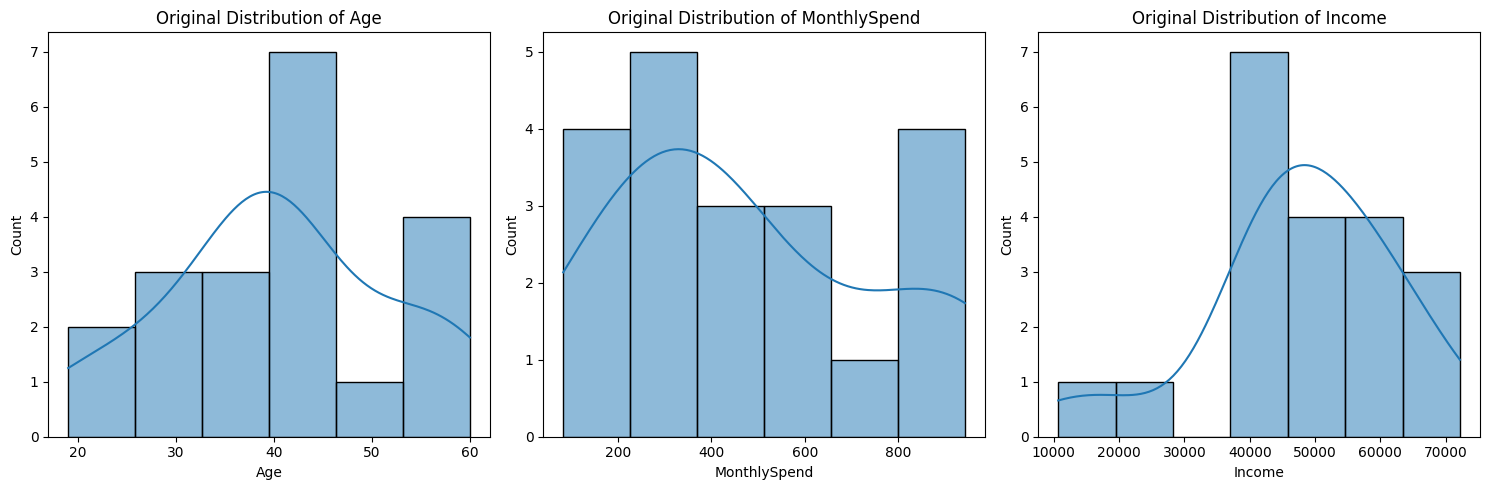

In [ ]:
# Let's use our df_for_outliers from the previous section as our base for scaling, ensuring numerical columns are clean.
# We'll work with a subset of numerical columns for demonstration.

df_scaled = df_for_outliers.copy()

# The numerical columns we want to scale
numerical_features_to_scale = ['Age', 'MonthlySpend', 'Income']

print("Original descriptive statistics for features to be scaled:")
display(df_scaled[numerical_features_to_scale].describe())

# Visualize original distributions
plt.figure(figsize=(15, 5))
for i, col in enumerate(numerical_features_to_scale):
    plt.subplot(1, 3, i + 1)
    sns.histplot(df_scaled[col], kde=True)
    plt.title(f'Original Distribution of {col}')
plt.tight_layout()
plt.show()

### 6.1 StandardScaler (Standardization)

`StandardScaler` transforms the data such that its mean is 0 and its standard deviation is 1. This is achieved by subtracting the mean from each value and then dividing by the standard deviation. It assumes that the data is normally distributed, but it works even if the distribution is not Gaussian. It's particularly useful when an algorithm assumes zero mean and unit variance.

Descriptive statistics after StandardScaler:


,Age,MonthlySpend,Income
count,2.000000e+01,2.000000e+01,2.000000e+01
mean,-2.393918e-17,4.440892e-16,1.165734e-16
std,1.025978e+00,1.025978e+00,1.025978e+00
min,-1.879540e+00,-1.396600e+00,-2.628641e+00
25%,-4.808126e-01,-6.888670e-01,-4.015525e-01
50%,-4.371023e-02,-3.025239e-01,8.112438e-02
75%,6.337984e-01,6.646993e-01,5.719021e-01
max,1.704699e+00,1.672904e+00,1.719874e+00


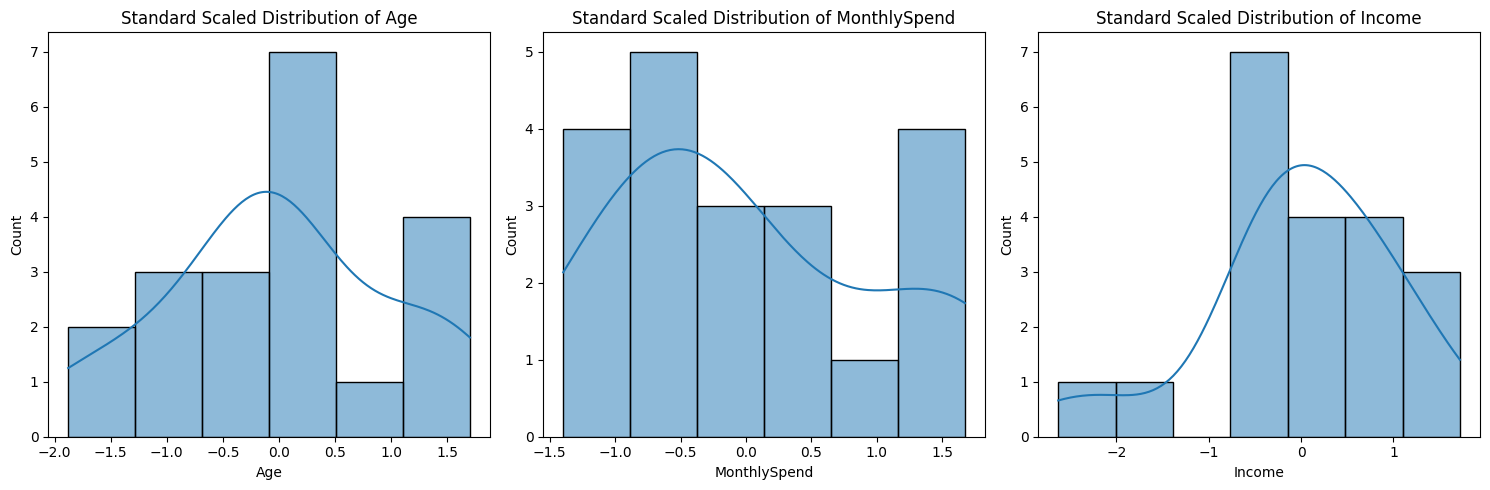

Note: Values are now centered around 0 with a standard deviation of 1.


In [ ]:
from sklearn.preprocessing import StandardScaler

df_standard_scaled = df_scaled.copy()

# Initialize the StandardScaler
scaler = StandardScaler()

# Apply StandardScaler to the selected numerical features
df_standard_scaled[numerical_features_to_scale] = scaler.fit_transform(df_standard_scaled[numerical_features_to_scale])

print("Descriptive statistics after StandardScaler:")
display(df_standard_scaled[numerical_features_to_scale].describe())

# Visualize distributions after scaling
plt.figure(figsize=(15, 5))
for i, col in enumerate(numerical_features_to_scale):
    plt.subplot(1, 3, i + 1)
    sns.histplot(df_standard_scaled[col], kde=True)
    plt.title(f'Standard Scaled Distribution of {col}')
plt.tight_layout()
plt.show()

print("Note: Values are now centered around 0 with a standard deviation of 1.")

### 6.2 MinMaxScaler (Normalization)

`MinMaxScaler` transforms features by scaling each feature to a given range, typically between 0 and 1. This is done by subtracting the minimum value and then dividing by the range (max - min). It is sensitive to outliers, as extreme values will significantly influence the min/max values and compress the majority of the data into a small range.

Descriptive statistics after MinMaxScaler:


,Age,MonthlySpend,Income
count,20.000000,20.000000,20.000000
mean,0.524390,0.454992,0.604492
std,0.286247,0.334249,0.235938
min,0.000000,0.000000,0.000000
25%,0.390244,0.230569,0.512149
50%,0.512195,0.356434,0.623147
75%,0.701220,0.671542,0.736008
max,1.000000,1.000000,1.000000


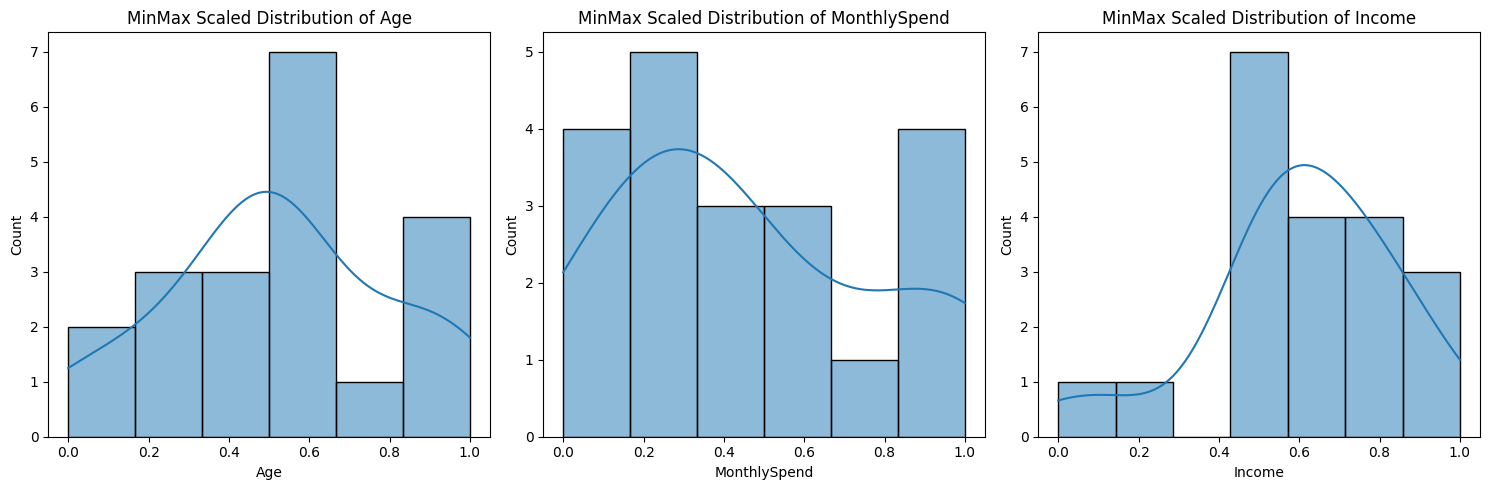

Note: Values are now scaled between 0 and 1.


In [ ]:
from sklearn.preprocessing import MinMaxScaler

df_min_max_scaled = df_scaled.copy()

# Initialize the MinMaxScaler
scaler = MinMaxScaler()

# Apply MinMaxScaler to the selected numerical features
df_min_max_scaled[numerical_features_to_scale] = scaler.fit_transform(df_min_max_scaled[numerical_features_to_scale])

print("Descriptive statistics after MinMaxScaler:")
display(df_min_max_scaled[numerical_features_to_scale].describe())

# Visualize distributions after scaling
plt.figure(figsize=(15, 5))
for i, col in enumerate(numerical_features_to_scale):
    plt.subplot(1, 3, i + 1)
    sns.histplot(df_min_max_scaled[col], kde=True)
    plt.title(f'MinMax Scaled Distribution of {col}')
plt.tight_layout()
plt.show()

print("Note: Values are now scaled between 0 and 1.")

### 6.3 RobustScaler

`RobustScaler` scales features using statistics that are robust to outliers. It scales data according to the Interquartile Range (IQR). It removes the median and scales the data according to the quantile range (defaults to IQR: 25th to 75th percentile). This method is particularly useful when the dataset contains many outliers, as it is not influenced by them as much as `StandardScaler` or `MinMaxScaler`.

Descriptive statistics after RobustScaler:


,Age,MonthlySpend,Income
count,20.000000,20.000000,2.000000e+01
mean,0.039216,0.223501,-8.333658e-02
std,0.920481,0.757982,1.053956e+00
min,-1.647059,-0.808292,-2.783659e+00
25%,-0.392157,-0.285426,-4.958391e-01
50%,0.000000,0.000000,-2.775558e-16
75%,0.607843,0.714574,5.041609e-01
max,1.568627,1.459425,1.683437e+00


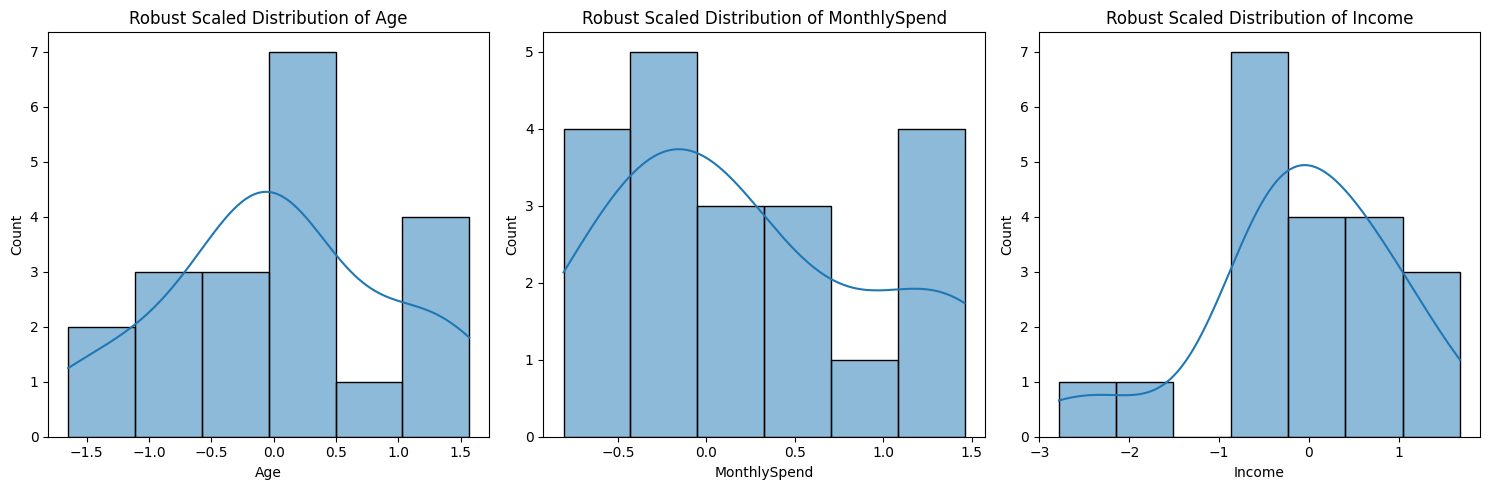

Note: Values are now scaled based on the median and IQR, making it robust to outliers.


In [ ]:
from sklearn.preprocessing import RobustScaler

df_robust_scaled = df_scaled.copy()

# Initialize the RobustScaler
scaler = RobustScaler()

# Apply RobustScaler to the selected numerical features
df_robust_scaled[numerical_features_to_scale] = scaler.fit_transform(df_robust_scaled[numerical_features_to_scale])

print("Descriptive statistics after RobustScaler:")
display(df_robust_scaled[numerical_features_to_scale].describe())

# Visualize distributions after scaling
plt.figure(figsize=(15, 5))
for i, col in enumerate(numerical_features_to_scale):
    plt.subplot(1, 3, i + 1)
    sns.histplot(df_robust_scaled[col], kde=True)
    plt.title(f'Robust Scaled Distribution of {col}')
plt.tight_layout()
plt.show()

print("Note: Values are now scaled based on the median and IQR, making it robust to outliers.")

### When to Use Which Scaler?

*   **StandardScaler**: Ideal when your data follows a Gaussian distribution or when algorithms assume zero mean and unit variance (e.g., Logistic Regression, SVMs, Linear Regression, Neural Networks).
*   **MinMaxScaler**: Useful when you need features to be within a specific range (e.g., 0-1 for image processing, or when using algorithms that are not robust to large variance in features like K-Means or Neural Networks with activation functions that are sensitive to scale). Be cautious with outliers.
*   **RobustScaler**: The best choice when your dataset contains many outliers and you want to minimize their influence on the scaling process. It's more resistant to the effects of outliers than `StandardScaler` or `MinMaxScaler`.

Always consider the characteristics of your data and the requirements of your chosen machine learning algorithm when deciding on a scaling technique.


### <div style="text-align: center;">--- End of Section 6 (Feature Scaling & Normalization) ---</div>

Having scaled our numerical features, we are now ready to tackle **Encoding Categorical Variables**, which is another critical preprocessing step for most machine learning models.

## 7. Encoding Categorical Variables

Most machine learning algorithms are designed to work with numerical data. Categorical variables, which represent qualities or categories (e.g., 'Gender', 'ProductCategory', 'Region'), need to be converted into a numerical format before they can be fed into a model. This process is known as **categorical encoding**.

### Types of Categorical Variables:

1.  **Nominal**: Categories without any intrinsic order (e.g., 'ProductCategory', 'Region', 'Gender').
2.  **Ordinal**: Categories with a clear, meaningful order (e.g., 'Rating' (1 to 5), 'Education Level' (High School, Bachelor's, Master's, PhD)).

Choosing the right encoding technique is vital, as an inappropriate choice can lead to misleading results or poor model performance.

Let's identify the categorical columns in our dataset and then apply different encoding methods.

In [ ]:
# Let's use our df_for_outliers from the previous section, ensuring numerical columns are clean.
# For this section, we'll work with the original categorical columns.

df_encoded = df.copy()

# Impute numerical missing values with median for a stable base
df_encoded['Age'].fillna(df_encoded['Age'].median(), inplace=True)
df_encoded['MonthlySpend'].fillna(df_encoded['MonthlySpend'].median(), inplace=True)

# For categorical columns with NaNs, let's fill with mode or 'Unknown' before encoding
df_encoded['Gender'].fillna(df_encoded['Gender'].mode()[0], inplace=True)
df_encoded['Region'].fillna('Unknown', inplace=True) # Treating 'nan' from synthetic data as a specific category 'Unknown'

print("DataFrame prepared for Categorical Encoding.")
print("Missing values check (should be none for relevant columns):")
display(df_encoded[['Age', 'MonthlySpend', 'Gender', 'Region']].isnull().sum())

categorical_cols = df_encoded.select_dtypes(include='object').columns.tolist()
print(f"\nCategorical columns identified: {categorical_cols}")

DataFrame prepared for Categorical Encoding.
Missing values check (should be none for relevant columns):


/tmp/ipykernel_9526/3240667190.py:7: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.



/tmp/ipykernel_9526/3240667190.py:8: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or

,0
Age,0
MonthlySpend,0
Gender,0
Region,0



Categorical columns identified: ['Gender', 'ProductCategory', 'Region']


### 7.1 OneHotEncoder (for Nominal Categorical Variables)

`OneHotEncoder` transforms nominal categorical features into a numerical format where each category value is converted into a new column, and assigned a 1 or 0 (true/false) value. This prevents the model from assuming an ordinal relationship between categories that do not exist. It's suitable for nominal variables where there is no inherent order.

**Disadvantage**: Can lead to a high-dimensional feature space, especially with many categories, which can cause the "curse of dimensionality" and increase computational cost.

In [ ]:
from sklearn.preprocessing import OneHotEncoder

df_onehot_encoded = df_encoded.copy()

# Identify nominal columns
nominal_cols = ['Gender', 'ProductCategory', 'Region'] # CustomerID is an identifier, not a feature to encode

# Initialize OneHotEncoder
# handle_unknown='ignore' prevents errors when encountering new categories during transform
# sparse_output=False returns a dense NumPy array
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Fit and transform the selected nominal columns
encoded_features = encoder.fit_transform(df_onehot_encoded[nominal_cols])

# Create a DataFrame from the encoded features with appropriate column names
encoded_df = pd.DataFrame(encoded_features, columns=encoder.get_feature_names_out(nominal_cols))

# Concatenate the encoded DataFrame with the original DataFrame (dropping original nominal columns)
df_onehot_encoded = pd.concat([df_onehot_encoded.drop(columns=nominal_cols), encoded_df], axis=1)

print("DataFrame head after One-Hot Encoding:")
display(df_onehot_encoded.head())
print(f"\nShape after One-Hot Encoding: {df_onehot_encoded.shape}")
print(f"New columns created: {encoder.get_feature_names_out(nominal_cols).tolist()}")

DataFrame head after One-Hot Encoding:


,CustomerID,Age,MonthlySpend,EnrollmentDate,Rating,Income,IsPrimeMember,Gender_Female,Gender_Male,ProductCategory_Books,ProductCategory_Clothing,ProductCategory_Electronics,ProductCategory_Groceries,Region_East,Region_North,Region_South,Region_West,Region_nan
0,101,56.0,82.67,2022-01-31,5,10703.82,True,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,102,40.0,913.85,2022-02-28,2,62328.54,False,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,103,46.0,295.84,2022-03-31,1,51305.71,False,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
3,104,32.0,389.15,2022-04-30,4,45514.89,False,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
4,105,60.0,346.13,2022-05-31,4,51376.41,True,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0



Shape after One-Hot Encoding: (20, 18)
New columns created: ['Gender_Female', 'Gender_Male', 'ProductCategory_Books', 'ProductCategory_Clothing', 'ProductCategory_Electronics', 'ProductCategory_Groceries', 'Region_East', 'Region_North', 'Region_South', 'Region_West', 'Region_nan']


### 7.2 OrdinalEncoder (for Ordinal Categorical Variables)

`OrdinalEncoder` is used for ordinal categorical variables where there is a meaningful order between categories. It assigns an integer to each category based on its order. It's crucial to specify the order correctly, as wrong ordering can confuse the model.

Our 'Rating' column (1-5) is a good example of an ordinal variable.

**Note**: If an `OrdinalEncoder` is applied to nominal data, the model might incorrectly assume an order, which can negatively impact performance, especially for linear models.

In [ ]:
from sklearn.preprocessing import OrdinalEncoder

df_ordinal_encoded = df_encoded.copy()

# The 'Rating' column is already numerical and ordinal (1 to 5).
# If it were represented as strings like 'Poor', 'Fair', 'Good', 'Very Good', 'Excellent', we would encode it.
# Let's create a hypothetical ordinal column for demonstration.
df_ordinal_encoded['ServiceLevel'] = np.random.choice(['Basic', 'Standard', 'Premium'], 20, p=[0.3, 0.5, 0.2])

# Define the order of categories for 'ServiceLevel'
service_level_categories = ['Basic', 'Standard', 'Premium']

# Initialize OrdinalEncoder with specified categories
encoder = OrdinalEncoder(categories=[service_level_categories])

# Apply OrdinalEncoder
df_ordinal_encoded['ServiceLevel_Encoded'] = encoder.fit_transform(df_ordinal_encoded[['ServiceLevel']])

print("DataFrame head showing original and ordinal encoded 'ServiceLevel':")
display(df_ordinal_encoded[['ServiceLevel', 'ServiceLevel_Encoded']].head())

print("\nUnique values of original 'ServiceLevel':", df_ordinal_encoded['ServiceLevel'].unique())
print("Unique values of encoded 'ServiceLevel':", df_ordinal_encoded['ServiceLevel_Encoded'].unique())

DataFrame head showing original and ordinal encoded 'ServiceLevel':


,ServiceLevel,ServiceLevel_Encoded
0,Basic,0.0
1,Basic,0.0
2,Standard,1.0
3,Standard,1.0
4,Basic,0.0



Unique values of original 'ServiceLevel': ['Basic' 'Standard' 'Premium']
Unique values of encoded 'ServiceLevel': [0. 1. 2.]


### 7.3 Target Encoding (Mean Encoding)

Target encoding (or Mean Encoding) is a more advanced technique, especially useful for high-cardinality categorical features (features with many unique categories). It replaces each category value with the mean of the target variable for that category. For example, if we were predicting `MonthlySpend`, each `ProductCategory` would be replaced by the average `MonthlySpend` for that `ProductCategory`.

**Advantages**:
*   Reduces dimensionality.
*   Captures more information than one-hot encoding for high-cardinality features.

**Disadvantages**:
*   Can lead to **data leakage** if not implemented carefully (e.g., using the target variable from the test set for encoding).
*   Prone to **overfitting** on the training data, especially with small categories.

To mitigate data leakage and overfitting, target encoding should ideally be performed using **cross-validation** (e.g., K-Fold Target Encoding) or on the training set only, then applied to the validation/test set. For this demonstration, we'll show a basic implementation without cross-validation, but always remember the caveat.

Let's assume we want to encode 'ProductCategory' based on 'MonthlySpend'.

In [ ]:
df_target_encoded = df_encoded.copy()

# The target variable for this example is 'MonthlySpend'
# Let's make sure 'MonthlySpend' has no NaNs for target encoding calculation
df_target_encoded['MonthlySpend'].fillna(df_target_encoded['MonthlySpend'].median(), inplace=True)

# Calculate the mean of 'MonthlySpend' for each 'ProductCategory'
# In a real scenario, this would be done on the training set to prevent data leakage.
target_encoding_map = df_target_encoded.groupby('ProductCategory')['MonthlySpend'].mean()

# Apply the target encoding to the 'ProductCategory' column
df_target_encoded['ProductCategory_TargetEncoded'] = df_target_encoded['ProductCategory'].map(target_encoding_map)

print("Target Encoding Map for 'ProductCategory':")
display(target_encoding_map)

print("\nDataFrame head showing original and target encoded 'ProductCategory':")
display(df_target_encoded[['ProductCategory', 'ProductCategory_TargetEncoded', 'MonthlySpend']].head())

# Let's visualize the relationship
fig = px.bar(target_encoding_map.reset_index(), x='ProductCategory', y='MonthlySpend',
             title='Average Monthly Spend by ProductCategory (Target Encoding)')
fig.update_layout(xaxis_title='Product Category', yaxis_title='Average Monthly Spend', height=400, width=600)
fig.show()

Target Encoding Map for 'ProductCategory':


/tmp/ipykernel_9526/1357971496.py:5: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.





,MonthlySpend
ProductCategory,
Books,103.236667
Clothing,656.560000
Electronics,535.015000
Groceries,441.252857



DataFrame head showing original and target encoded 'ProductCategory':


,ProductCategory,ProductCategory_TargetEncoded,MonthlySpend
0,Books,103.236667,82.67
1,Clothing,656.560000,913.85
2,Groceries,441.252857,295.84
3,Electronics,535.015000,389.15
4,Groceries,441.252857,346.13


### Other Encoding Techniques:

*   **Frequency/Count Encoding**: Replaces categories with their frequency or count in the dataset. Good for high cardinality features and less prone to data leakage.
*   **Binary Encoding**: First, categories are mapped to ordinal numbers, then those integers are converted into binary code, and each bit is a new column.
*   **Hash Encoding**: Converts categories into numerical features using a hash function. Useful for very high cardinality features to control dimensionality.

The choice of encoding method depends heavily on the nature of the categorical variable, the cardinality, the type of machine learning model, and the potential for data leakage.


### <div style="text-align: center;">--- End of Section 7 (Encoding Categorical Variables) ---</div>

Now that we've learned how to transform categorical data into numerical, our next step is **Feature Engineering**, where we'll create new, more informative features from existing ones.

## 8. Feature Engineering

Feature Engineering is the process of creating new features from existing raw data to help machine learning models perform better. It is a critical step that often determines the success of a project, as the quality of features directly impacts the model's ability to learn and generalize. Effective feature engineering relies heavily on domain knowledge and creativity.

### Why Feature Engineering?

*   **Improve Model Accuracy**: Better features allow models to capture more complex patterns.
*   **Reduce Overfitting**: Well-engineered features can sometimes simplify the model, reducing the risk of overfitting.
*   **Accelerate Training**: Fewer, more relevant features can speed up model training.
*   **Enhance Interpretability**: Some engineered features can make model decisions more understandable.

Let's generate some new features from our synthetic dataset.

In [ ]:
# Let's use our df_encoded (which has imputed missing values) as the base for feature engineering.
df_engineered = df_encoded.copy()

print("Original DataFrame head before Feature Engineering:")
display(df_engineered.head())

Original DataFrame head before Feature Engineering:


,CustomerID,Age,Gender,ProductCategory,MonthlySpend,EnrollmentDate,Rating,Region,Income,IsPrimeMember
0,101,56.0,Male,Books,82.67,2022-01-31,5,West,10703.82,True
1,102,40.0,Male,Clothing,913.85,2022-02-28,2,North,62328.54,False
2,103,46.0,Male,Groceries,295.84,2022-03-31,1,South,51305.71,False
3,104,32.0,Male,Electronics,389.15,2022-04-30,4,North,45514.89,False
4,105,60.0,Male,Groceries,346.13,2022-05-31,4,nan,51376.41,True


### 8.1 Creating Features from Date/Time Data

Date and time columns often contain rich information that can be extracted into numerical or categorical features. Common extractions include year, month, day of week, day of month, week of year, and whether it's a weekend.

In [ ]:
print("\n--- Feature Engineering from 'EnrollmentDate' ---")

df_engineered['Enrollment_Year'] = df_engineered['EnrollmentDate'].dt.year
df_engineered['Enrollment_Month'] = df_engineered['EnrollmentDate'].dt.month
df_engineered['Enrollment_DayOfWeek'] = df_engineered['EnrollmentDate'].dt.dayofweek # Monday=0, Sunday=6
df_engineered['Enrollment_DayOfYear'] = df_engineered['EnrollmentDate'].dt.dayofyear
df_engineered['Enrollment_IsWeekend'] = df_engineered['EnrollmentDate'].dt.dayofweek.apply(lambda x: 1 if x >= 5 else 0)

# Example: Days since a reference date (e.g., beginning of data collection)
reference_date = pd.to_datetime('2022-01-01')
df_engineered['Days_Since_Enrollment_Start'] = (df_engineered['EnrollmentDate'] - reference_date).dt.days

print("DataFrame head with new date-based features:")
display(df_engineered[['EnrollmentDate', 'Enrollment_Year', 'Enrollment_Month',
                       'Enrollment_DayOfWeek', 'Enrollment_IsWeekend', 'Days_Since_Enrollment_Start']].head())


--- Feature Engineering from 'EnrollmentDate' ---
DataFrame head with new date-based features:


,EnrollmentDate,Enrollment_Year,Enrollment_Month,Enrollment_DayOfWeek,Enrollment_IsWeekend,Days_Since_Enrollment_Start
0,2022-01-31,2022,1,0,0,30
1,2022-02-28,2022,2,0,0,58
2,2022-03-31,2022,3,3,0,89
3,2022-04-30,2022,4,5,1,119
4,2022-05-31,2022,5,1,0,150


### 8.2 Creating Interaction Features

Interaction features capture the combined effect of two or more independent features. For example, if the effect of 'MonthlySpend' on a target variable changes based on 'IsPrimeMember', an interaction term between these two features might be useful.

In [ ]:
print("\n--- Creating Interaction Features ---")

# Example 1: Interaction between 'MonthlySpend' and 'Age'
df_engineered['Age_x_MonthlySpend'] = df_engineered['Age'] * df_engineered['MonthlySpend']

# Example 2: Interaction between 'MonthlySpend' and 'IsPrimeMember' (numerical interaction)
# Assuming IsPrimeMember is True=1, False=0. If it's boolean, convert it.
if df_engineered['IsPrimeMember'].dtype == 'bool':
    df_engineered['IsPrimeMember_int'] = df_engineered['IsPrimeMember'].astype(int)
else:
    df_engineered['IsPrimeMember_int'] = df_engineered['IsPrimeMember'] # already numeric

df_engineered['MonthlySpend_x_IsPrimeMember'] = df_engineered['MonthlySpend'] * df_engineered['IsPrimeMember_int']

print("DataFrame head with new interaction features:")
display(df_engineered[['Age', 'MonthlySpend', 'IsPrimeMember', 'IsPrimeMember_int',
                       'Age_x_MonthlySpend', 'MonthlySpend_x_IsPrimeMember']].head())


--- Creating Interaction Features ---
DataFrame head with new interaction features:


,Age,MonthlySpend,IsPrimeMember,IsPrimeMember_int,Age_x_MonthlySpend,MonthlySpend_x_IsPrimeMember
0,56.0,82.67,True,1,4629.52,82.67
1,40.0,913.85,False,0,36554.00,0.00
2,46.0,295.84,False,0,13608.64,0.00
3,32.0,389.15,False,0,12452.80,0.00
4,60.0,346.13,True,1,20767.80,346.13


### 8.3 Creating Polynomial Features

Polynomial features are typically used to capture non-linear relationships between features and the target variable. For a feature `X`, polynomial features might include `X^2`, `X^3`, etc. This can be combined with interaction terms (`X*Y`, `X^2*Y`, etc.).

In [ ]:
from sklearn.preprocessing import PolynomialFeatures

print("\n--- Creating Polynomial Features ---")

# Let's create polynomial features for 'Age' and 'Income'
poly = PolynomialFeatures(degree=2, include_bias=False)

# Select features for polynomial transformation
features_for_poly = ['Age', 'Income']
X_poly = df_engineered[features_for_poly]

# Fit and transform
poly_features = poly.fit_transform(X_poly)

# Create a DataFrame for the new polynomial features
poly_feature_names = poly.get_feature_names_out(features_for_poly)
df_poly_features = pd.DataFrame(poly_features, columns=poly_feature_names, index=df_engineered.index)

# Add these new features back to our main DataFrame
df_engineered = pd.concat([df_engineered, df_poly_features], axis=1)

print("DataFrame head with new polynomial features:")
display(df_engineered[poly_feature_names].head())
print(f"New polynomial features created: {poly_feature_names.tolist()}")


--- Creating Polynomial Features ---
DataFrame head with new polynomial features:


,Age,Age,Income,Income,Age^2,Age Income,Income^2
0,56.0,56.0,10703.82,10703.82,3136.0,599413.92,1.145718e+08
1,40.0,40.0,62328.54,62328.54,1600.0,2493141.60,3.884847e+09
2,46.0,46.0,51305.71,51305.71,2116.0,2360062.66,2.632276e+09
3,32.0,32.0,45514.89,45514.89,1024.0,1456476.48,2.071605e+09
4,60.0,60.0,51376.41,51376.41,3600.0,3082584.60,2.639536e+09


New polynomial features created: ['Age', 'Income', 'Age^2', 'Age Income', 'Income^2']


### 8.4 Aggregation Features (Domain Knowledge Example)

Aggregation features involve summarizing information across groups. For example, calculating the average 'MonthlySpend' for each 'ProductCategory' or 'Region'. This often requires domain knowledge about what aggregations might be meaningful.

Since our dataset is small, some aggregations might not show strong patterns, but the concept is important.

In [ ]:
print("\n--- Creating Aggregation Features (example) ---")

# Example: Average Monthly Spend by Region
# This assumes 'Region' has already been handled for NaNs and is ready for grouping.
# Note: This is an example, in a real scenario, you'd calculate this on the training data
# and then map it to test/validation sets to prevent data leakage.

# Calculate mean monthly spend per region
region_avg_spend = df_engineered.groupby('Region')['MonthlySpend'].transform('mean')
df_engineered['Region_AvgMonthlySpend'] = region_avg_spend

# Example: Count of customers per Product Category
product_category_counts = df_engineered.groupby('ProductCategory')['CustomerID'].transform('count')
df_engineered['ProductCategory_CustomerCount'] = product_category_counts

print("DataFrame head with new aggregation features:")
display(df_engineered[['Region', 'MonthlySpend', 'Region_AvgMonthlySpend',
                       'ProductCategory', 'ProductCategory_CustomerCount']].head())

print(f"Final shape of DataFrame after feature engineering: {df_engineered.shape}")


--- Creating Aggregation Features (example) ---
DataFrame head with new aggregation features:


,Region,MonthlySpend,Region_AvgMonthlySpend,ProductCategory,ProductCategory_CustomerCount
0,West,82.67,459.675714,Books,3
1,North,913.85,415.670000,Clothing,6
2,South,295.84,510.185000,Groceries,7
3,North,389.15,415.670000,Electronics,4
4,nan,346.13,482.065000,Groceries,7


Final shape of DataFrame after feature engineering: (20, 26)


### Best Practices in Feature Engineering:

*   **Domain Knowledge is Key**: Leverage your understanding of the problem domain to create meaningful features.
*   **Start Simple**: Begin with straightforward transformations and aggregations.
*   **Iterate and Experiment**: Feature engineering is an iterative process. Experiment with different ideas and evaluate their impact on model performance.
*   **Avoid Data Leakage**: Be extremely careful when creating features that rely on information from the target variable, especially if you are using aggregations or target encoding. Always perform these operations within the training set and then apply them to the validation/test set.
*   **Keep it Interpretable**: While complex features can be powerful, simpler, interpretable features are often preferred.
*   **Automated Feature Engineering**: Tools like Featuretools or deep learning techniques are emerging for automating parts of this process (Future Trends Section 12).


### <div style="text-align: center;">--- End of Section 8 (Feature Engineering) ---</div>

With our data now cleaned, scaled, encoded, and enriched with new features, we are ready to move on to **Advanced Pipelines**, which will show how to combine all these preprocessing steps into a robust and reproducible workflow.

## 9. Advanced Pipeline: ColumnTransformer + Pipeline

In real-world machine learning projects, preprocessing steps are rarely isolated. We often need to apply different transformations to different subsets of columns (e.g., numerical features need scaling, categorical features need encoding, and some columns might be dropped). Manually applying these transformations can be cumbersome, error-prone, and difficult to manage.

`scikit-learn`'s `Pipeline` and `ColumnTransformer` provide a powerful way to streamline and automate these preprocessing steps. This ensures that our data transformations are consistent, reproducible, and prevent common pitfalls like data leakage.

### Why use Pipelines and ColumnTransformer?

1.  **Code Organization**: Keeps all preprocessing steps in one place, making code cleaner and easier to understand.
2.  **Reproducibility**: Ensures the same transformations are applied to new data (e.g., test sets, production data) in the exact same order and with the same learned parameters (e.g., mean/std from training data).
3.  **Prevents Data Leakage**: `Pipeline` ensures that `fit()` is only called on the training data, and `transform()` is called on both training and test data, avoiding information leakage from the test set into the training process.
4.  **Hyperparameter Tuning**: Simplifies hyperparameter tuning of both estimators and preprocessors using `GridSearchCV` or `RandomizedSearchCV`.

Let's build a comprehensive preprocessing pipeline for our synthetic dataset.

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder, OrdinalEncoder
from sklearn.ensemble import RandomForestClassifier # Example model for the end of the pipeline
from sklearn.model_selection import train_test_split

# Let's re-load the original dataset to demonstrate the full pipeline from scratch
np.random.seed(42) # for reproducibility

data = {
    'CustomerID': np.arange(101, 121),
    'Age': np.random.randint(18, 70, 20),
    'Gender': np.random.choice(['Male', 'Female', 'Other'], 20, p=[0.45, 0.5, 0.05]),
    'ProductCategory': np.random.choice(['Electronics', 'Clothing', 'Books', 'Groceries'], 20),
    'MonthlySpend': np.random.uniform(50, 1000, 20).round(2),
    'EnrollmentDate': pd.to_datetime(pd.date_range(start='2022-01-01', periods=20, freq='M')),
    'Rating': np.random.randint(1, 6, 20),
    'Region': np.random.choice(['North', 'South', 'East', 'West', np.nan], 20, p=[0.2, 0.2, 0.2, 0.2, 0.2]), # Introducing NaNs
    'Income': np.random.normal(50000, 15000, 20).round(2),
    'IsPrimeMember': np.random.choice([True, False], 20, p=[0.3, 0.7])
}

df_pipeline = pd.DataFrame(data)

# Introduce some more missing values artificially for demonstration
df_pipeline.loc[[1, 5, 12], 'Age'] = np.nan
df_pipeline.loc[[3, 8], 'MonthlySpend'] = np.nan
df_pipeline.loc[[0, 10], 'Gender'] = np.nan
df_pipeline.loc[[4, 11], 'ProductCategory'] = np.nan # Add NaN to a categorical column

print("Original DataFrame for Pipeline (with NaNs):")
display(df_pipeline.head())
print("Missing values:")
display(df_pipeline.isnull().sum()[df_pipeline.isnull().sum() > 0])

Original DataFrame for Pipeline (with NaNs):


/tmp/ipykernel_9526/1899703739.py:17: FutureWarning:

'M' is deprecated and will be removed in a future version, please use 'ME' instead.



,CustomerID,Age,Gender,ProductCategory,MonthlySpend,EnrollmentDate,Rating,Region,Income,IsPrimeMember
0,101,56.0,NaN,Books,82.67,2022-01-31,5,West,10703.82,True
1,102,NaN,Male,Clothing,913.85,2022-02-28,2,North,62328.54,False
2,103,46.0,Male,Groceries,295.84,2022-03-31,1,South,51305.71,False
3,104,32.0,Male,Electronics,NaN,2022-04-30,4,North,45514.89,False
4,105,60.0,Male,NaN,346.13,2022-05-31,4,nan,51376.41,True


Missing values:


,0
Age,3
Gender,2
ProductCategory,2
MonthlySpend,2


### 9.1 Defining Features and Target

First, we need to clearly define which columns are numerical, categorical (nominal/ordinal), and which is our target variable. For this example, let's assume we want to predict `IsPrimeMember` (a binary classification task).

In [ ]:
# Define target variable (y) and features (X)
X = df_pipeline.drop('IsPrimeMember', axis=1)
y = df_pipeline['IsPrimeMember'].astype(int) # Convert boolean target to int (0 or 1)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

# Identify column types
numerical_features = ['Age', 'MonthlySpend', 'Income', 'Rating']
nominal_categorical_features = ['Gender', 'ProductCategory', 'Region']
ordinal_categorical_features = [] # No explicitly ordinal categorical features other than 'Rating' which is numerical
date_features = ['EnrollmentDate']
id_features = ['CustomerID']

print(f"\nNumerical Features: {numerical_features}")
print(f"Nominal Categorical Features: {nominal_categorical_features}")
print(f"Ordinal Categorical Features (explicitly encoded): {ordinal_categorical_features}")
print(f"Date Features: {date_features}")
print(f"ID Features: {id_features}")

X_train shape: (16, 9)
X_test shape: (4, 9)
y_train shape: (16,)
y_test shape: (4,)

Numerical Features: ['Age', 'MonthlySpend', 'Income', 'Rating']
Nominal Categorical Features: ['Gender', 'ProductCategory', 'Region']
Ordinal Categorical Features (explicitly encoded): []
Date Features: ['EnrollmentDate']
ID Features: ['CustomerID']


### 9.2 Creating Preprocessing Steps

We'll define separate pipelines for numerical and categorical features, and then combine them using `ColumnTransformer`.

In [ ]:
# --- 1. Numerical Features Pipeline ---
# Strategy: Impute missing values with the median, then scale using StandardScaler.

numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# --- 2. Nominal Categorical Features Pipeline ---
# Strategy: Impute missing values with the most frequent value, then One-Hot Encode.
# handle_unknown='ignore' is crucial to prevent errors if new categories appear in test set.

nominal_categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# --- 3. Ordinal Categorical Features (if any) ---
# For 'Rating', it's already numerical. If we had string ordinal like ['Poor', 'Good', 'Excellent'],
# we would use OrdinalEncoder with specified categories.
# Since our 'Rating' is numerical, it will go through the numerical pipeline.
# Let's create a placeholder for 'ProductCategory' if we want to treat it as ordinal in another scenario
# For this example, 'ProductCategory' is nominal.

# --- 4. Date Feature Engineering (as a custom transformer) ---
# This is a bit more advanced, as ColumnTransformer expects standard scikit-learn transformers.
# For simplicity, we'll manually engineer date features and then pass them through a numerical pipeline.
# In a more complex scenario, you might create a custom transformer for this.

# For now, let's add date features *before* the ColumnTransformer for demonstration simplicity.
# In a production-grade pipeline, this would ideally be a custom transformer within the ColumnTransformer.

def feature_engineer_dates(df_input):
    df = df_input.copy()
    df['Enrollment_Month'] = df['EnrollmentDate'].dt.month
    df['Enrollment_DayOfWeek'] = df['EnrollmentDate'].dt.dayofweek
    df['Enrollment_IsWeekend'] = df['EnrollmentDate'].dt.dayofweek.apply(lambda x: 1 if x >= 5 else 0)
    return df.drop(columns=['EnrollmentDate'])

X_train_fe = feature_engineer_dates(X_train)
X_test_fe = feature_engineer_dates(X_test)

# Update feature lists after date engineering
numerical_features_updated = numerical_features + ['Enrollment_Month', 'Enrollment_DayOfWeek', 'Enrollment_IsWeekend']

print("Individual transformers defined.")

Individual transformers defined.


### 9.3 Combining with ColumnTransformer

`ColumnTransformer` allows applying different transformers to different columns. Columns not specified in `transformers` are usually dropped or passed through.

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features_updated),
        ('cat', nominal_categorical_transformer, nominal_categorical_features)
    ],
    remainder='drop' # Drops any columns not specified
)

print("ColumnTransformer created.")

ColumnTransformer created.


### 9.4 Building the Full Pipeline

Finally, we combine the `preprocessor` with a machine learning model into a `Pipeline`. For this example, we'll use a `RandomForestClassifier`.

In [ ]:
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

print("Full machine learning pipeline created.")

print("\n--- Training the Pipeline ---")
model_pipeline.fit(X_train_fe, y_train)
print("Pipeline training complete.")

print("\n--- Evaluating the Pipeline ---")
# Evaluate on training data
train_accuracy = model_pipeline.score(X_train_fe, y_train)
print(f"Training Accuracy: {train_accuracy:.4f}")

# Evaluate on test data
test_accuracy = model_pipeline.score(X_test_fe, y_test)
print(f"Test Accuracy: {test_accuracy:.4f}")

# Get predictions (example)
y_pred = model_pipeline.predict(X_test_fe)
print(f"\nSample predictions on test set: {y_pred[:5]}")
print(f"Actual labels for sample predictions: {y_test.head().tolist()}")

# Accessing transformed data (for inspection/debugging)
# You can access intermediate steps' output if needed.
# transformed_X_train = model_pipeline.named_steps['preprocessor'].fit_transform(X_train_fe)
# print(f"\nShape of transformed training data: {transformed_X_train.shape}")

Full machine learning pipeline created.

--- Training the Pipeline ---
Pipeline training complete.

--- Evaluating the Pipeline ---
Training Accuracy: 1.0000
Test Accuracy: 0.7500

Sample predictions on test set: [0 0 0 0]
Actual labels for sample predictions: [0, 1, 0, 0]


### Best Practices for Pipelines:

*   **Custom Transformers**: For complex feature engineering (like the date feature extraction), create custom `BaseEstimator` and `TransformerMixin` compatible classes. This allows them to be seamlessly integrated into `Pipeline`.
*   **Hyperparameter Tuning**: Use `GridSearchCV` or `RandomizedSearchCV` on the entire `Pipeline` object to tune hyperparameters for both preprocessing steps and the final model simultaneously.
*   **Inspection**: Use `pipeline.named_steps['step_name']` to access individual steps within the pipeline after fitting.
*   **Save and Load**: Use `joblib` to save the fitted pipeline for deployment (covered in Section 11).

This end-to-end pipeline ensures that all your preprocessing and modeling steps are applied consistently and correctly, making your machine learning workflow robust and ready for production.

### <div style="text-align: center;">--- End of Section 9 (Advanced Pipeline) ---</div>

With our robust preprocessing pipeline in place, the next logical step is **Feature Selection**, where we identify the most impactful features for our model.

### 10.1 Filter Methods

Filter methods select features based on their individual scores with respect to the target variable or based on statistical properties, without involving any machine learning model. These methods are generally faster and computationally less expensive.

#### 10.1.1 Variance Threshold

The `VarianceThreshold` feature selector removes all features whose variance does not meet a certain threshold. By default, it removes features with zero variance, i.e., features that have the same value in all samples. This is useful for removing constant features, which provide no discriminatory information to a model.

In [ ]:
from sklearn.feature_selection import VarianceThreshold

# Let's use our df_engineered from the previous section.
df_feature_selection = df_engineered.copy()

# For simplicity, let's select numerical features to demonstrate.
# We will drop the 'CustomerID' and 'EnrollmentDate' as they are identifiers/timestamps.
# We also need to drop categorical features that are not yet encoded for this method.

# Let's re-encode gender and Region with one-hot encoding for this section to get numerical representation
df_feature_selection = pd.get_dummies(df_feature_selection, columns=['Gender', 'ProductCategory', 'Region'], drop_first=True)

# Drop other non-numerical or redundant columns for this demonstration
X_fs = df_feature_selection.drop(columns=[
    'CustomerID', 'EnrollmentDate', 'IsPrimeMember', 'IsPrimeMember_int',
    'ServiceLevel', 'ServiceLevel_Encoded'
], errors='ignore')

print("Original features for Variance Thresholding:")
display(X_fs.head())
print(f"Original number of features: {X_fs.shape[1]}")

# Apply VarianceThreshold
# threshold=0.0 will remove all zero-variance features (constant features).
# We can set a higher threshold to remove low-variance features too.
selector = VarianceThreshold(threshold=0.0)
selector.fit(X_fs)

# Get selected features
X_fs_reduced = X_fs.loc[:, selector.get_support(indices=False)]

print("\nFeatures after Variance Threshold (threshold=0.0):")
display(X_fs_reduced.head())
print(f"Number of features after variance threshold: {X_fs_reduced.shape[1]}")

removed_features = [col for col in X_fs.columns if col not in X_fs_reduced.columns]
if removed_features:
    print(f"Removed features (zero variance): {removed_features}")
else:
    print("No features with zero variance were found.")


Original features for Variance Thresholding:


,Age,MonthlySpend,Rating,Income,Enrollment_Year,Enrollment_Month,Enrollment_DayOfWeek,Enrollment_DayOfYear,Enrollment_IsWeekend,Days_Since_Enrollment_Start,...,Region_AvgMonthlySpend,ProductCategory_CustomerCount,Gender_Male,ProductCategory_Clothing,ProductCategory_Electronics,ProductCategory_Groceries,Region_North,Region_South,Region_West,Region_nan
0,56.0,82.67,5,10703.82,2022,1,0,31,0,30,...,459.675714,3,True,False,False,False,False,False,True,False
1,40.0,913.85,2,62328.54,2022,2,0,59,0,58,...,415.670000,6,True,True,False,False,True,False,False,False
2,46.0,295.84,1,51305.71,2022,3,3,90,0,89,...,510.185000,7,True,False,False,True,False,True,False,False
3,32.0,389.15,4,45514.89,2022,4,5,120,1,119,...,415.670000,4,True,False,True,False,True,False,False,False
4,60.0,346.13,4,51376.41,2022,5,1,151,0,150,...,482.065000,7,True,False,False,True,False,False,False,True


Original number of features: 27

Features after Variance Threshold (threshold=0.0):


,Age,MonthlySpend,Rating,Income,Enrollment_Year,Enrollment_Month,Enrollment_DayOfWeek,Enrollment_DayOfYear,Enrollment_IsWeekend,Days_Since_Enrollment_Start,...,Region_AvgMonthlySpend,ProductCategory_CustomerCount,Gender_Male,ProductCategory_Clothing,ProductCategory_Electronics,ProductCategory_Groceries,Region_North,Region_South,Region_West,Region_nan
0,56.0,82.67,5,10703.82,2022,1,0,31,0,30,...,459.675714,3,True,False,False,False,False,False,True,False
1,40.0,913.85,2,62328.54,2022,2,0,59,0,58,...,415.670000,6,True,True,False,False,True,False,False,False
2,46.0,295.84,1,51305.71,2022,3,3,90,0,89,...,510.185000,7,True,False,False,True,False,True,False,False
3,32.0,389.15,4,45514.89,2022,4,5,120,1,119,...,415.670000,4,True,False,True,False,True,False,False,False
4,60.0,346.13,4,51376.41,2022,5,1,151,0,150,...,482.065000,7,True,False,False,True,False,False,False,True


Number of features after variance threshold: 27
No features with zero variance were found.


#### 10.1.2 Univariate Feature Selection (SelectKBest / SelectPercentile)

Univariate feature selection methods examine each feature individually to determine its relationship with the target variable. These methods are simple, fast, and often provide good insights into the data. `SelectKBest` and `SelectPercentile` are two common tools from `sklearn.feature_selection`.

We need to choose an appropriate scoring function based on the data type of the features and the target variable:

*   **For classification tasks:**
    *   `chi2` (Chi-squared): For non-negative features (e.g., one-hot encoded categorical) and a categorical target.
    *   `f_classif` (ANOVA F-value): For numerical features and a categorical target.

*   **For regression tasks:**
    *   `f_regression` (ANOVA F-value): For numerical features and a numerical target.

Since our implied target variable (`IsPrimeMember`) is categorical (binary), we will use `f_classif` for numerical features and `chi2` for one-hot encoded categorical features.


In [ ]:
from sklearn.feature_selection import SelectKBest, chi2, f_classif

# Prepare data for SelectKBest
# We need a numerical representation of all features, and a numerical target.

# Re-load a clean copy of the original df to ensure we start fresh for feature selection examples
df_selectkbest = df.copy()

# Handle missing values as done previously for robust imputation/encoding
df_selectkbest['Age'].fillna(df_selectkbest['Age'].median(), inplace=True)
df_selectkbest['MonthlySpend'].fillna(df_selectkbest['MonthlySpend'].median(), inplace=True)
df_selectkbest['Gender'].fillna(df_selectkbest['Gender'].mode()[0], inplace=True)
df_selectkbest['Region'].fillna('Unknown', inplace=True)

# Drop CustomerID and EnrollmentDate as they are not features for selection
df_selectkbest = df_selectkbest.drop(columns=['CustomerID', 'EnrollmentDate'])

# Convert 'IsPrimeMember' to numeric (0 or 1) - our target variable (y)
y_fs = df_selectkbest['IsPrimeMember'].astype(int)
X_fs = df_selectkbest.drop(columns=['IsPrimeMember'])

# Identify numerical and categorical columns for different scoring functions
numerical_cols_fs = X_fs.select_dtypes(include=np.number).columns.tolist()
categorical_cols_fs = X_fs.select_dtypes(include='object').columns.tolist()

print("Original features before encoding for SelectKBest:")
display(X_fs.head())
print(f"Numerical features: {numerical_cols_fs}")
print(f"Categorical features: {categorical_cols_fs}")

# --- Process Categorical Features with One-Hot Encoding and Chi2 ---
# We need to one-hot encode categorical features first for chi2.
# Let's perform One-Hot Encoding for categorical features
X_fs_encoded = pd.get_dummies(X_fs, columns=categorical_cols_fs, drop_first=True)

# Separate numerical features and one-hot encoded categorical features
X_numerical = X_fs_encoded[numerical_cols_fs]
X_categorical_encoded = X_fs_encoded.drop(columns=numerical_cols_fs)

print("\nFeatures after One-Hot Encoding for SelectKBest (categorical parts):")
display(X_categorical_encoded.head())

# Apply SelectKBest with chi2 for categorical features
# Select top 'k' features based on chi2 score
k_categorical = min(5, X_categorical_encoded.shape[1]) # Select up to 5, or all if fewer
selector_chi2 = SelectKBest(chi2, k=k_categorical)
selector_chi2.fit(X_categorical_encoded, y_fs)

X_categorical_selected = X_categorical_encoded.loc[:, selector_chi2.get_support()]
print(f"\nSelected {X_categorical_selected.shape[1]} categorical features using chi2:")
display(X_categorical_selected.head())
print(f"Features selected: {X_categorical_selected.columns.tolist()}")

# --- Apply SelectKBest with f_classif for numerical features ---
k_numerical = min(4, X_numerical.shape[1]) # Select up to 4, or all if fewer
selector_fclassif = SelectKBest(f_classif, k=k_numerical)
selector_fclassif.fit(X_numerical, y_fs)

X_numerical_selected = X_numerical.loc[:, selector_fclassif.get_support()]
print(f"\nSelected {X_numerical_selected.shape[1]} numerical features using f_classif:")
display(X_numerical_selected.head())
print(f"Features selected: {X_numerical_selected.columns.tolist()}")

# --- Combine selected features ---
X_fs_final = pd.concat([X_numerical_selected, X_categorical_selected], axis=1)

print(f"\nTotal features selected after SelectKBest (chi2 + f_classif): {X_fs_final.shape[1]}")
display(X_fs_final.head())


Original features before encoding for SelectKBest:


/tmp/ipykernel_9526/4191507189.py:10: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.



/tmp/ipykernel_9526/4191507189.py:11: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' 

,Age,Gender,ProductCategory,MonthlySpend,Rating,Region,Income
0,56.0,Male,Books,82.67,5,West,10703.82
1,40.0,Male,Clothing,913.85,2,North,62328.54
2,46.0,Male,Groceries,295.84,1,South,51305.71
3,32.0,Male,Electronics,389.15,4,North,45514.89
4,60.0,Male,Groceries,346.13,4,nan,51376.41


Numerical features: ['Age', 'MonthlySpend', 'Rating', 'Income']
Categorical features: ['Gender', 'ProductCategory', 'Region']

Features after One-Hot Encoding for SelectKBest (categorical parts):


,Gender_Male,ProductCategory_Clothing,ProductCategory_Electronics,ProductCategory_Groceries,Region_North,Region_South,Region_West,Region_nan
0,True,False,False,False,False,False,True,False
1,True,True,False,False,True,False,False,False
2,True,False,False,True,False,True,False,False
3,True,False,True,False,True,False,False,False
4,True,False,False,True,False,False,False,True


...

,Gender_Male,ProductCategory_Clothing,ProductCategory_Groceries,Region_West,Region_nan
0,True,False,False,True,False
1,True,True,False,False,False
2,True,False,True,False,False
3,True,False,False,False,False
4,True,False,True,False,True


Features selected: ['Gender_Male', 'ProductCategory_Clothing', 'ProductCategory_Groceries', 'Region_West', 'Region_nan']

Selected 4 numerical features using f_classif:


,Age,MonthlySpend,Rating,Income
0,56.0,82.67,5,10703.82
1,40.0,913.85,2,62328.54
2,46.0,295.84,1,51305.71
3,32.0,389.15,4,45514.89
4,60.0,346.13,4,51376.41


Features selected: ['Age', 'MonthlySpend', 'Rating', 'Income']

Total features selected after SelectKBest (chi2 + f_classif): 9


,Age,MonthlySpend,Rating,Income,Gender_Male,ProductCategory_Clothing,ProductCategory_Groceries,Region_West,Region_nan
0,56.0,82.67,5,10703.82,True,False,False,True,False
1,40.0,913.85,2,62328.54,True,True,False,False,False
2,46.0,295.84,1,51305.71,True,False,True,False,False
3,32.0,389.15,4,45514.89,True,False,False,False,False
4,60.0,346.13,4,51376.41,True,False,True,False,True


### 10.2 Wrapper Methods

Wrapper methods evaluate different subsets of features by training and testing a specific machine learning model on each subset. These methods often yield better predictive accuracy than filter methods because they consider the interaction between features and the chosen model. However, they are computationally more expensive.

Popular wrapper methods include:
*   **Forward Selection**: Start with no features and add the one that provides the best improvement to the model.
*   **Backward Elimination**: Start with all features and remove the one that causes the least performance degradation.
*   **Recursive Feature Elimination (RFE)**: Recursively removes features and builds a model on the remaining features.

We will demonstrate Forward Selection using `SequentialFeatureSelector`.

#### 10.2.1 Sequential Feature Selector (Forward Selection)

`SequentialFeatureSelector` (SFS) is a greedy algorithm used to find the best subset of features. Forward Selection (SFS with `direction='forward'`) starts with an empty set of features and iteratively adds the feature that, when added, results in the best model performance. This continues until the desired number of features is reached or no further improvement can be made.

In [ ]:
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.linear_model import LogisticRegression

# Re-load a clean copy of the original df for this section to ensure consistency
df_sfs = df.copy()

# Handle missing values and encode categorical features as done in the pipeline section
df_sfs['Age'].fillna(df_sfs['Age'].median(), inplace=True)
df_sfs['MonthlySpend'].fillna(df_sfs['MonthlySpend'].median(), inplace=True)
df_sfs['Gender'].fillna(df_sfs['Gender'].mode()[0], inplace=True)
df_sfs['Region'].fillna('Unknown', inplace=True)

# Convert 'IsPrimeMember' to numeric (0 or 1) - our target variable (y)
y_sfs = df_sfs['IsPrimeMember'].astype(int)
X_sfs = df_sfs.drop(columns=['CustomerID', 'EnrollmentDate', 'IsPrimeMember'])

# One-hot encode all categorical features, as SFS requires numerical input
categorical_cols_sfs = X_sfs.select_dtypes(include='object').columns.tolist()
X_sfs_encoded = pd.get_dummies(X_sfs, columns=categorical_cols_sfs, drop_first=True)

# Scale numerical features (optional, but good practice for many models like Logistic Regression)
numerical_cols_sfs = X_sfs_encoded.select_dtypes(include=np.number).columns.tolist()
scaler_sfs = StandardScaler()
X_sfs_encoded[numerical_cols_sfs] = scaler_sfs.fit_transform(X_sfs_encoded[numerical_cols_sfs])

print("Features prepared for Sequential Feature Selection (SFS):")
display(X_sfs_encoded.head())
print(f"Initial number of features: {X_sfs_encoded.shape[1]}")

# Initialize a base estimator (e.g., Logistic Regression)
estimator = LogisticRegression(max_iter=1000, random_state=42)

# Initialize SFS for forward selection
# n_features_to_select: number of features to select ('auto', 'half', int, float)
# direction: 'forward' or 'backward'
# cv: cross-validation strategy
sfs = SequentialFeatureSelector(estimator, n_features_to_select=5, direction='forward', cv=3, n_jobs=-1)

# Fit SFS
sfs.fit(X_sfs_encoded, y_sfs)

# Get the selected features
selected_features_sfs = X_sfs_encoded.columns[sfs.get_support()].tolist()
X_sfs_reduced = X_sfs_encoded[selected_features_sfs]

print(f"\nFeatures selected using Forward Selection (SFS): {selected_features_sfs}")
print(f"Number of features after SFS: {X_sfs_reduced.shape[1]}")
display(X_sfs_reduced.head())

Features prepared for Sequential Feature Selection (SFS):


/tmp/ipykernel_9526/324395847.py:8: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.



/tmp/ipykernel_9526/324395847.py:9: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or d

,Age,MonthlySpend,Rating,Income,Gender_Male,ProductCategory_Clothing,ProductCategory_Electronics,ProductCategory_Groceries,Region_North,Region_South,Region_West,Region_nan
0,1.355017,-1.396600,1.379936,-2.628641,True,False,False,False,False,False,True,False
1,-0.043710,1.570557,-0.545556,1.023720,True,True,False,False,True,False,False,False
2,0.480813,-0.635623,-1.187387,0.243873,True,False,False,True,False,True,False,False
3,-0.743074,-0.302524,0.738105,-0.165817,True,False,True,False,True,False,False,False
4,1.704699,-0.456097,0.738105,0.248875,True,False,False,True,False,False,False,True


Initial number of features: 12

Features selected using Forward Selection (SFS): ['Rating', 'Income', 'Gender_Male', 'ProductCategory_Electronics', 'ProductCategory_Groceries']
Number of features after SFS: 5


,Rating,Income,Gender_Male,ProductCategory_Electronics,ProductCategory_Groceries
0,1.379936,-2.628641,True,False,False
1,-0.545556,1.023720,True,False,False
2,-1.187387,0.243873,True,False,True
3,0.738105,-0.165817,True,True,False
4,0.738105,0.248875,True,False,True


#### 10.2.2 Recursive Feature Elimination (RFE)

Recursive Feature Elimination (RFE) is a wrapper-type feature selection algorithm. It works by fitting a model and eliminating the weakest feature (or features) until the specified number of features is reached. The 'weakest' features are determined by the `coef_` attribute (for linear models) or `feature_importances_` attribute (for tree-based models) of the estimator.

RFE requires a base estimator that provides either feature importances or coefficients. It's often used with models like Logistic Regression, Support Vector Machines, or Decision Trees.


In [ ]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression

# Re-load a clean copy of the original df for this section to ensure consistency
df_rfe = df.copy()

# Handle missing values and encode categorical features as done in the pipeline section
df_rfe['Age'].fillna(df_rfe['Age'].median(), inplace=True)
df_rfe['MonthlySpend'].fillna(df_rfe['MonthlySpend'].median(), inplace=True)
df_rfe['Gender'].fillna(df_rfe['Gender'].mode()[0], inplace=True)
df_rfe['Region'].fillna('Unknown', inplace=True)

# Convert 'IsPrimeMember' to numeric (0 or 1) - our target variable (y)
y_rfe = df_rfe['IsPrimeMember'].astype(int)
X_rfe = df_rfe.drop(columns=['CustomerID', 'EnrollmentDate', 'IsPrimeMember'])

# One-hot encode all categorical features, as RFE requires numerical input
categorical_cols_rfe = X_rfe.select_dtypes(include='object').columns.tolist()
X_rfe_encoded = pd.get_dummies(X_rfe, columns=categorical_cols_rfe, drop_first=True)

# Scale numerical features (optional, but good practice for many models like Logistic Regression)
numerical_cols_rfe = X_rfe_encoded.select_dtypes(include=np.number).columns.tolist()
scaler_rfe = StandardScaler()
X_rfe_encoded[numerical_cols_rfe] = scaler_rfe.fit_transform(X_rfe_encoded[numerical_cols_rfe])

print("Features prepared for Recursive Feature Elimination (RFE):")
display(X_rfe_encoded.head())
print(f"Initial number of features: {X_rfe_encoded.shape[1]}")

# Initialize a base estimator (e.g., Logistic Regression)
estimator_rfe = LogisticRegression(max_iter=1000, random_state=42)

# Initialize RFE
# n_features_to_select: The number of features to select.
# step: The number of features to remove at each iteration.
rfe_selector = RFE(estimator=estimator_rfe, n_features_to_select=5, step=1)

# Fit RFE
rfe_selector.fit(X_rfe_encoded, y_rfe)

# Get the selected features
selected_features_rfe = X_rfe_encoded.columns[rfe_selector.get_support()].tolist()
X_rfe_reduced = X_rfe_encoded[selected_features_rfe]

print(f"\nFeatures selected using RFE: {selected_features_rfe}")
print(f"Number of features after RFE: {X_rfe_reduced.shape[1]}")
display(X_rfe_reduced.head())

print("\nFeature ranking:")
print(pd.Series(rfe_selector.ranking_, index=X_rfe_encoded.columns).sort_values())


Features prepared for Recursive Feature Elimination (RFE):


/tmp/ipykernel_9526/553359868.py:8: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.



/tmp/ipykernel_9526/553359868.py:9: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or d

,Age,MonthlySpend,Rating,Income,Gender_Male,ProductCategory_Clothing,ProductCategory_Electronics,ProductCategory_Groceries,Region_North,Region_South,Region_West,Region_nan
0,1.355017,-1.396600,1.379936,-2.628641,True,False,False,False,False,False,True,False
1,-0.043710,1.570557,-0.545556,1.023720,True,True,False,False,True,False,False,False
2,0.480813,-0.635623,-1.187387,0.243873,True,False,False,True,False,True,False,False
3,-0.743074,-0.302524,0.738105,-0.165817,True,False,True,False,True,False,False,False
4,1.704699,-0.456097,0.738105,0.248875,True,False,False,True,False,False,False,True


Initial number of features: 12

Features selected using RFE: ['Age', 'MonthlySpend', 'Income', 'ProductCategory_Electronics', 'Region_North']
Number of features after RFE: 5


,Age,MonthlySpend,Income,ProductCategory_Electronics,Region_North
0,1.355017,-1.396600,-2.628641,False,False
1,-0.043710,1.570557,1.023720,False,True
2,0.480813,-0.635623,0.243873,False,False
3,-0.743074,-0.302524,-0.165817,True,True
4,1.704699,-0.456097,0.248875,False,False



Feature ranking:
Age                            1
MonthlySpend                   1
Income                         1
ProductCategory_Electronics    1
Region_North                   1
Gender_Male                    2
Rating                         3
ProductCategory_Groceries      4
Region_nan                     5
Region_South                   6
Region_West                    7
ProductCategory_Clothing       8
dtype: int64


### 10.3 Embedded Methods

Embedded methods perform feature selection as part of the model training process. These methods combine the qualities of filter and wrapper methods by learning which features contribute most to the model's accuracy during training. They are typically less computationally intensive than wrapper methods and can capture feature interactions.

Examples of embedded methods include:
*   **Lasso (L1) Regularization**: Penalizes the absolute size of the regression coefficients, effectively shrinking some coefficients to zero and thus performing feature selection.
*   **Tree-based methods**: Decision trees, Random Forests, Gradient Boosting Machines inherently perform feature selection by using feature importance scores.

#### 10.3.1 Lasso (L1) Regularization

Lasso (Least Absolute Shrinkage and Selection Operator) is a type of linear regression that uses shrinkage. Shrinkage means that coefficients for some features are shrunk to zero, which means those features are effectively removed from the model. This makes Lasso a very useful technique for feature selection, especially when you have a large number of features.

In [ ]:
from sklearn.linear_model import LogisticRegression

# Re-load a clean copy of the original df for this section to ensure consistency
df_lasso = df.copy()

# Handle missing values and encode categorical features
df_lasso['Age'].fillna(df_lasso['Age'].median(), inplace=True)
df_lasso['MonthlySpend'].fillna(df_lasso['MonthlySpend'].median(), inplace=True)
df_lasso['Gender'].fillna(df_lasso['Gender'].mode()[0], inplace=True)
df_lasso['Region'].fillna('Unknown', inplace=True)

# Convert 'IsPrimeMember' to numeric (0 or 1) - our target variable (y)
y_lasso = df_lasso['IsPrimeMember'].astype(int)
X_lasso = df_lasso.drop(columns=['CustomerID', 'EnrollmentDate', 'IsPrimeMember'])

# One-hot encode all categorical features, as Lasso requires numerical input
categorical_cols_lasso = X_lasso.select_dtypes(include='object').columns.tolist()
X_lasso_encoded = pd.get_dummies(X_lasso, columns=categorical_cols_lasso, drop_first=True)

# Scale numerical features for Lasso, as it's sensitive to feature scales
numerical_cols_lasso = X_lasso_encoded.select_dtypes(include=np.number).columns.tolist()
scaler_lasso = StandardScaler()
X_lasso_encoded[numerical_cols_lasso] = scaler_lasso.fit_transform(X_lasso_encoded[numerical_cols_lasso])

print("Features prepared for Lasso Regularization:")
display(X_lasso_encoded.head())
print(f"Initial number of features: {X_lasso_encoded.shape[1]}")

# Initialize Logistic Regression with L1 penalty (Lasso)
# C is the inverse of regularization strength; smaller values specify stronger regularization.
# solver='liblinear' or 'saga' support L1 penalty.
lasso_model = LogisticRegression(penalty='l1', C=0.1, solver='liblinear', random_state=42)

# Fit the model
lasso_model.fit(X_lasso_encoded, y_lasso)

# Get feature coefficients
coefficients = pd.Series(lasso_model.coef_[0], index=X_lasso_encoded.columns)

print("\nFeature coefficients from Lasso (L1) Regularization:")
display(coefficients.sort_values(ascending=False))

# Select features with non-zero coefficients
selected_features_lasso = coefficients[coefficients != 0].index.tolist()
X_lasso_reduced = X_lasso_encoded[selected_features_lasso]

print(f"\nFeatures selected by Lasso (non-zero coefficients): {selected_features_lasso}")
print(f"Number of features after Lasso: {X_lasso_reduced.shape[1]}")
display(X_lasso_reduced.head())


Features prepared for Lasso Regularization:


/tmp/ipykernel_9526/4077373495.py:7: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.



/tmp/ipykernel_9526/4077373495.py:8: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or

,Age,MonthlySpend,Rating,Income,Gender_Male,ProductCategory_Clothing,ProductCategory_Electronics,ProductCategory_Groceries,Region_North,Region_South,Region_West,Region_nan
0,1.355017,-1.396600,1.379936,-2.628641,True,False,False,False,False,False,True,False
1,-0.043710,1.570557,-0.545556,1.023720,True,True,False,False,True,False,False,False
2,0.480813,-0.635623,-1.187387,0.243873,True,False,False,True,False,True,False,False
3,-0.743074,-0.302524,0.738105,-0.165817,True,False,True,False,True,False,False,False
4,1.704699,-0.456097,0.738105,0.248875,True,False,False,True,False,False,False,True


Initial number of features: 12

Feature coefficients from Lasso (L1) Regularization:


,0
Age,0.0
MonthlySpend,0.0
Rating,0.0
Income,0.0
Gender_Male,0.0
ProductCategory_Clothing,0.0
ProductCategory_Electronics,0.0
ProductCategory_Groceries,0.0
Region_North,0.0
Region_South,0.0



Features selected by Lasso (non-zero coefficients): []
Number of features after Lasso: 0


""
0
1
2
3
4


#### 10.3.2 Tree-based Feature Importance

Tree-based models (Decision Trees, Random Forests, Gradient Boosting) can be used for feature selection because they inherently compute a feature importance score. This score indicates how useful or valuable each feature is in the construction of the boosted decision trees within the model.

*   **How it works**: Features that are used more often in the splits, or features that lead to larger reductions in impurity (e.g., Gini impurity or entropy for classification, mean squared error for regression), are considered more important.
*   **Advantages**: Relatively fast, can capture non-linear relationships, and don't require feature scaling.


In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Re-load a clean copy of the original df for this section to ensure consistency
df_tree_importance = df.copy()

# Handle missing values and encode categorical features
df_tree_importance['Age'].fillna(df_tree_importance['Age'].median(), inplace=True)
df_tree_importance['MonthlySpend'].fillna(df_tree_importance['MonthlySpend'].median(), inplace=True)
df_tree_importance['Gender'].fillna(df_tree_importance['Gender'].mode()[0], inplace=True)
df_tree_importance['Region'].fillna('Unknown', inplace=True)

# Convert 'IsPrimeMember' to numeric (0 or 1) - our target variable (y)
y_tree = df_tree_importance['IsPrimeMember'].astype(int)
X_tree = df_tree_importance.drop(columns=['CustomerID', 'EnrollmentDate', 'IsPrimeMember'])

# One-hot encode all categorical features
categorical_cols_tree = X_tree.select_dtypes(include='object').columns.tolist()
X_tree_encoded = pd.get_dummies(X_tree, columns=categorical_cols_tree, drop_first=True)

# No need for scaling with tree-based models

print("Features prepared for Tree-based Feature Importance:")
display(X_tree_encoded.head())
print(f"Initial number of features: {X_tree_encoded.shape[1]}")

# Initialize a RandomForestClassifier
model_rf = RandomForestClassifier(n_estimators=100, random_state=42)

# Fit the model
model_rf.fit(X_tree_encoded, y_tree)

# Get feature importances
feature_importances = pd.Series(model_rf.feature_importances_, index=X_tree_encoded.columns)

print("\nFeature importances from RandomForestClassifier:")
display(feature_importances.sort_values(ascending=False))

# Select top N features (e.g., top 5)
top_n = 5
selected_features_rf = feature_importances.nlargest(top_n).index.tolist()
X_tree_reduced = X_tree_encoded[selected_features_rf]

print(f"\nTop {top_n} features selected by RandomForestClassifier: {selected_features_rf}")
print(f"Number of features after selection: {X_tree_reduced.shape[1]}")
display(X_tree_reduced.head())


Features prepared for Tree-based Feature Importance:


/tmp/ipykernel_9526/2721556593.py:7: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.



/tmp/ipykernel_9526/2721556593.py:8: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or

,Age,MonthlySpend,Rating,Income,Gender_Male,ProductCategory_Clothing,ProductCategory_Electronics,ProductCategory_Groceries,Region_North,Region_South,Region_West,Region_nan
0,56.0,82.67,5,10703.82,True,False,False,False,False,False,True,False
1,40.0,913.85,2,62328.54,True,True,False,False,True,False,False,False
2,46.0,295.84,1,51305.71,True,False,False,True,False,True,False,False
3,32.0,389.15,4,45514.89,True,False,True,False,True,False,False,False
4,60.0,346.13,4,51376.41,True,False,False,True,False,False,False,True


Initial number of features: 12

Feature importances from RandomForestClassifier:


,0
MonthlySpend,0.274874
Age,0.223131
Income,0.196767
Rating,0.070176
Gender_Male,0.044952
ProductCategory_Groceries,0.039896
ProductCategory_Clothing,0.036188
Region_nan,0.034975
Region_North,0.022865
Region_West,0.022844



Top 5 features selected by RandomForestClassifier: ['MonthlySpend', 'Age', 'Income', 'Rating', 'Gender_Male']
Number of features after selection: 5


,MonthlySpend,Age,Income,Rating,Gender_Male
0,82.67,56.0,10703.82,5,True
1,913.85,40.0,62328.54,2,True
2,295.84,46.0,51305.71,1,True
3,389.15,32.0,45514.89,4,True
4,346.13,60.0,51376.41,4,True


### Best Practices for Feature Selection:

*   **Understand Your Data and Problem**: Domain knowledge is invaluable. Some features might be logically more important than others.
*   **Start with Filter Methods**: They are fast and can quickly eliminate irrelevant features, especially for high-dimensional datasets.
*   **Combine Methods**: Often, a combination of methods works best. For example, use filter methods to reduce the feature space, then wrapper or embedded methods on the reduced set.
*   **Avoid Data Leakage**: Especially with wrapper and embedded methods, ensure that feature selection is performed only on the training data to avoid leaking information from the test set.
*   **Cross-Validation**: Use cross-validation to evaluate the performance of your model with different feature subsets. This helps in getting a more robust estimate of performance.
*   **Simplicity vs. Performance**: Aim for a balance. A simpler model with fewer features is often easier to interpret and deploy, even if it has a slightly lower performance.
*   **Iterate**: Feature selection is an iterative process. You might go back and forth between feature engineering, selection, and model training to find the optimal set of features.

### <div style="text-align: center;">--- End of Section 10 (Feature Selection) ---</div>

Now that our data is prepared and optimized with relevant features, it's time to learn how to operationalize our machine learning workflows effectively. Next, we will delve into **MLOps & Production Best Practices**.

## 11. MLOps & Production Best Practices

MLOps (Machine Learning Operations) is a set of practices that aims to deploy and maintain ML systems in production reliably and efficiently. It's an extension of DevOps principles to the machine learning lifecycle, encompassing data preparation, model training, deployment, monitoring, and management. For B.Tech AI & DS students, understanding MLOps is crucial for transitioning from academic projects to real-world applications.

### Why MLOps Matters in 2026 (Industry Standard):

1.  **Reproducibility**: Ensures that models can be recreated consistently, from data preprocessing to training and deployment.
2.  **Scalability**: Allows ML systems to handle increasing data volumes and user traffic.
3.  **Reliability**: Guarantees that deployed models are stable and perform as expected in production.
4.  **Version Control**: Manages changes to code, data, models, and environments, facilitating collaboration and rollback capabilities.
5.  **Monitoring**: Tracks model performance, data drift, and system health in real-time to identify and address issues promptly.
6.  **Automation**: Automates repetitive tasks in the ML lifecycle, such as retraining, testing, and deployment.
7.  **Compliance & Governance**: Ensures ML systems adhere to regulatory requirements and ethical guidelines.

In this section, we'll cover some fundamental MLOps practices, focusing on saving and loading pipelines, which is essential for consistent model deployment.

### 11.1 Saving and Loading Trained Models/Pipelines (`joblib`)

Once a machine learning model or an entire preprocessing pipeline is trained and validated, it needs to be saved so it can be deployed for making predictions on new, unseen data without having to retrain it every time. `joblib` (or `pickle`) is the standard Python library for this purpose.

Saving the entire pipeline (including preprocessing steps and the model) is a best practice. This ensures that the exact same transformations applied during training are also applied to new data, preventing inconsistencies and potential performance degradation.

In [ ]:
import joblib
import os

# We will use the 'model_pipeline' that we created and trained in Section 9.
# This pipeline includes all preprocessing steps (imputation, scaling, encoding) and the classifier.

# --- 1. Define a file path for saving the pipeline ---
model_filename = 'full_preprocessing_model_pipeline.joblib'

# --- 2. Save the trained pipeline ---
print(f"Saving the trained pipeline to {model_filename}...")
joblib.dump(model_pipeline, model_filename)
print("Pipeline saved successfully!")

# --- 3. Load the saved pipeline ---
print(f"\nLoading the pipeline from {model_filename}...")
loaded_model_pipeline = joblib.load(model_filename)
print("Pipeline loaded successfully!")

# --- 4. Verify the loaded pipeline can make predictions ---
print("\nVerifying loaded pipeline with test data...")

# Use the pre-processed X_test_fe and y_test from Section 9

# Make predictions with the loaded pipeline
y_pred_loaded = loaded_model_pipeline.predict(X_test_fe)

# Evaluate accuracy (using the same metric as before for consistency)
from sklearn.metrics import accuracy_score
loaded_accuracy = accuracy_score(y_test, y_pred_loaded)

print(f"Accuracy of the loaded pipeline on test set: {loaded_accuracy:.4f}")

# Check if predictions are identical to the original pipeline's predictions
# (y_pred was generated in Section 9)
if 'y_pred' in globals() and (y_pred == y_pred_loaded).all():
    print("Predictions from original and loaded pipelines are identical. Success!")
else:
    print("Predictions might differ slightly or y_pred was not found. Please check manually.")

# Clean up the saved file (optional)
# os.remove(model_filename)
# print(f"Cleaned up: Removed {model_filename}")


Saving the trained pipeline to full_preprocessing_model_pipeline.joblib...
Pipeline saved successfully!

Loading the pipeline from full_preprocessing_model_pipeline.joblib...
Pipeline loaded successfully!

Verifying loaded pipeline with test data...
Accuracy of the loaded pipeline on test set: 0.7500
Predictions from original and loaded pipelines are identical. Success!


### 11.2 Other MLOps Best Practices

Beyond just saving and loading models, several other practices are vital for robust ML systems:

*   **Version Control Everything**: Use tools like Git for code, DVC (Data Version Control) for data, and MLflow/WandB for model versions. This ensures reproducibility and traceability.
*   **Automated Testing**: Implement unit tests for data preprocessing functions, integration tests for pipelines, and model quality tests (e.g., performance thresholds, fairness metrics).
*   **Containerization (Docker)**: Package your application and its dependencies into isolated containers. This ensures consistency across different environments (development, staging, production).
*   **Orchestration (Kubernetes)**: Manage containerized applications, enabling scaling, self-healing, and declarative deployment of ML services.
*   **CI/CD for ML (CI/CD/CT)**: Continuous Integration (CI) for code changes, Continuous Delivery (CD) for deployment, and Continuous Training (CT) for automated model retraining based on new data or performance degradation.
*   **Monitoring and Alerting**: Deploy dashboards and alerts to track model performance metrics (accuracy, F1-score), data quality metrics (drift, anomalies), and infrastructure health in real-time.
*   **Feature Stores**: Centralized repositories for curated, versioned, and production-ready features. They ensure consistency between features used for training and inference.
*   **Explainability (XAI)**: Integrate tools (e.g., SHAP, LIME) to understand model predictions, which is crucial for debugging, auditing, and regulatory compliance.

By adopting these MLOps practices, B.Tech AI & DS students can build more reliable, scalable, and maintainable machine learning systems, preparing them for the demands of the 2026 industry landscape.

### <div style="text-align: center;">--- End of Section 11 (MLOps & Production Best Practices) ---</div>

As you embark on your journey in AI & DS, it's essential to keep an eye on the horizon. The field is constantly evolving, with new tools and techniques emerging. Let's look at what the **2026 Future Trends** in data preprocessing might hold.

## 12. 2026 Future Trends in Data Preprocessing

The landscape of data science and machine learning is ever-changing. What's considered best practice today might be automated or superseded by new technologies tomorrow. For B.Tech AI & DS students, staying abreast of these emerging trends is crucial for future-proofing your skills. Here are some key trends expected to be mainstream by 2026:

### 12.1 Automated Data Preprocessing (AutoML 2.0)

AutoML (Automated Machine Learning) is moving beyond just model selection and hyperparameter tuning to encompass the entire ML pipeline, including preprocessing. Tools are becoming more sophisticated at:

*   **Automated Missing Value Imputation**: Intelligently choosing the best imputation strategy (mean, median, KNN, iterative imputer, or even model-based imputation) based on data characteristics and problem type.
*   **Automated Feature Scaling and Encoding**: Automatically detecting feature types and applying appropriate scaling (StandardScaler, MinMaxScaler, RobustScaler) and encoding (One-Hot, Ordinal, Target Encoding) without manual intervention.
*   **Automated Outlier Detection and Treatment**: Employing advanced algorithms (like IsolationForest, DBSCAN) to identify and suggest treatment for outliers.
*   **Automated Feature Engineering**: Generating new features from raw data (e.g., date features, interaction terms, polynomial features) automatically, and then selecting the most relevant ones.

Platforms like Google Cloud AutoML Tables, H2O Driverless AI, and open-source libraries are leading this charge, making preprocessing more efficient and less prone to human error.

### 12.2 Synthetic Data Generation

As data privacy concerns (GDPR, CCPA) intensify, access to real-world sensitive data becomes increasingly restricted. **Synthetic data generation** is emerging as a powerful solution, expected to be a standard practice by 2026.

*   **What it is**: Artificially generated data that statistically resembles real-world data but contains no identifiable information from actual individuals.
*   **Use Cases**:
    *   **Privacy Preservation**: Shareable datasets for development, testing, and external collaboration without compromising privacy.
    *   **Data Augmentation**: Expanding small datasets, especially in domains like healthcare or rare event detection, to improve model robustness.
    *   **Bias Mitigation**: Generating synthetic samples for underrepresented groups to balance datasets and reduce algorithmic bias.
    *   **Testing and Simulation**: Creating diverse scenarios for testing complex ML systems before real-world deployment.

Techniques include Generative Adversarial Networks (GANs), Variational Autoencoders (VAEs), and statistical modeling approaches. This trend allows for innovation while adhering to strict privacy regulations.

### 12.3 Feature Stores

By 2026, Feature Stores are expected to be a standard component of enterprise MLOps platforms. A feature store is a centralized repository that allows data scientists to discover, create, share, and serve machine learning features efficiently and consistently.

*   **What it is**: A data system that standardizes the definition, storage, and access of features for machine learning models. It bridges the gap between data engineering and machine learning.
*   **Key Benefits**:
    *   **Consistency**: Ensures that the same features, computed using the same logic, are used for both model training and online inference, eliminating training-serving skew.
    *   **Reusability**: Features can be created once and reused across multiple models and teams, reducing redundant work.
    *   **Version Control**: Tracks different versions of features, allowing for reproducibility and rollback.
    *   **Low Latency Serving**: Optimizes for fast retrieval of features during online inference, critical for real-time applications.
    *   **Monitoring**: Enables monitoring of feature quality and freshness.

Prominent examples include open-source solutions like Feast and commercial offerings from cloud providers (e.g., Google Cloud Vertex AI Feature Store). Understanding and utilizing feature stores will be a key skill for AI & DS professionals.

### 12.4 Responsible AI and Ethical Preprocessing

As AI becomes more pervasive, the focus on **Responsible AI** practices is intensifying, and this begins squarely with data preprocessing. By 2026, it will be standard for AI & DS professionals to actively consider and mitigate ethical concerns in their data pipelines.

*   **Bias Detection and Mitigation**: Tools and techniques to identify and reduce bias in datasets (e.g., gender bias, racial bias). This involves analyzing feature distributions across different demographic groups and applying debiasing techniques (e.g., re-weighting, adversarial debiasing) during preprocessing.
*   **Fairness Metrics Integration**: Integrating fairness metrics (e.g., demographic parity, equalized odds) directly into preprocessing and model evaluation workflows to ensure equitable outcomes across different groups.
*   **Explainable Preprocessing (XPP)**: Developing methods to understand how preprocessing choices (e.g., imputation, encoding, scaling) impact downstream model performance and fairness. This is part of the broader Explainable AI (XAI) movement.
*   **Privacy-Preserving Techniques**: Beyond synthetic data, adopting techniques like Federated Learning, Differential Privacy, and Homomorphic Encryption to enable model training on sensitive data without direct exposure of individual records.
*   **Data Governance and Auditability**: Establishing clear policies and tools for tracking data lineage, transformations, and access controls, ensuring that preprocessing decisions are auditable and compliant with regulations.

### <div style="text-align: center;">--- End of Section 12 (2026 Future Trends) ---</div>

These trends highlight that data preprocessing is an ever-evolving field. As you continue your studies and career in AI & DS, embrace continuous learning and adaptation to new tools and methodologies. Next, it's time to apply what you've learned with some practical exercises!

## 13. Exercises + Mini Projects (with Solutions)

Welcome to the hands-on practice section! This is where you can apply the concepts and techniques you've learned throughout this notebook. Each exercise is designed to reinforce your understanding of data preprocessing steps. Try to solve them on your own first before peeking at the solutions.

### Exercise Structure:

*   **Problem Statement**: Describes the task.
*   **Hint (Optional)**: Provides a little push if you get stuck.
*   **Solution**: The complete code to solve the exercise.

Let's get started!

### Exercise 1: Missing Value Imputation with a Twist

**Problem Statement**: You have a dataset with missing 'Age' values. Instead of a simple mean/median, you want to impute 'Age' based on 'Gender'. That is, fill missing 'Age' for males with the mean age of males, and for females with the mean age of females. If 'Gender' is also missing, use the overall mean age.

**Steps:**
1.  Create a copy of the original `df` for this exercise.
2.  Identify and handle any missing 'Gender' values first (e.g., fill with mode or 'Unknown').
3.  Calculate the mean 'Age' for each gender category.
4.  Impute missing 'Age' values using these gender-specific means. If 'Gender' was originally missing (and now filled with 'Unknown'), use the overall mean age.
5.  Verify that there are no more missing 'Age' values.

In [ ]:
# --- Exercise 1: Your Code Here ---
# Make sure to handle the original NaNs in Gender first.
# You might need to make a temporary column for original gender for logic.

df_ex1 = df.copy()

# Step 1 & 2: Handle missing 'Gender' first and track original NaNs
df_ex1['Original_Gender_is_NaN'] = df_ex1['Gender'].isnull()
mode_gender_ex1 = df_ex1['Gender'].mode()[0]
df_ex1['Gender'].fillna(mode_gender_ex1, inplace=True)

# Step 3: Calculate gender-specific mean ages
mean_age_male = df_ex1[df_ex1['Gender'] == 'Male']['Age'].mean()
mean_age_female = df_ex1[df_ex1['Gender'] == 'Female']['Age'].mean()
mean_age_other = df_ex1[df_ex1['Gender'] == 'Other']['Age'].mean()
overall_mean_age = df_ex1['Age'].mean()

print(f"Mean Age Male: {mean_age_male:.2f}")
print(f"Mean Age Female: {mean_age_female:.2f}")
print(f"Mean Age Other: {mean_age_other:.2f}")
print(f"Overall Mean Age: {overall_mean_age:.2f}")

# Step 4: Impute missing 'Age' values
def impute_age_by_gender(row):
    if pd.isna(row['Age']):
        if row['Original_Gender_is_NaN']:
            return overall_mean_age
        elif row['Gender'] == 'Male':
            return mean_age_male
        elif row['Gender'] == 'Female':
            return mean_age_female
        elif row['Gender'] == 'Other':
            return mean_age_other # Or overall_mean_age if 'Other' is rare
    return row['Age']

df_ex1['Age'] = df_ex1.apply(impute_age_by_gender, axis=1)

# Step 5: Verify
print("\nMissing values after Exercise 1:")
display(df_ex1[['Age', 'Gender']].isnull().sum())
display(df_ex1[['CustomerID', 'Age', 'Gender', 'Original_Gender_is_NaN']].head(7))

# Clean up temporary column
df_ex1.drop(columns=['Original_Gender_is_NaN'], inplace=True)


Mean Age Male: 43.42
Mean Age Female: 33.80
Mean Age Other: nan
Overall Mean Age: 40.59

Missing values after Exercise 1:


/tmp/ipykernel_9526/4023366912.py:10: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.





,0
Age,0
Gender,0


,CustomerID,Age,Gender,Original_Gender_is_NaN
0,101,56.000000,Male,True
1,102,43.416667,Male,False
2,103,46.000000,Male,False
3,104,32.000000,Male,False
4,105,60.000000,Male,False
5,106,33.800000,Female,False
6,107,38.000000,Male,False


### Exercise 2: Outlier Treatment by Capping

**Problem Statement**: The 'MonthlySpend' column might contain outliers. Using the IQR method, identify outliers and then cap them at the upper and lower bounds (Winsorization).

**Steps:**
1.  Create a copy of the original `df` for this exercise.
2.  Calculate the Q1, Q3, and IQR for the 'MonthlySpend' column.
3.  Determine the lower and upper bounds for outlier detection.
4.  Cap the 'MonthlySpend' values: any value below the lower bound should be replaced with the lower bound, and any value above the upper bound should be replaced with the upper bound.
5.  Verify the capping by checking the descriptive statistics and distribution (e.g., using a box plot or histogram).

In [ ]:
# --- Exercise 2: Your Code Here ---

df_ex2 = df.copy()

# Impute MonthlySpend NaNs if any, as IQR calculation would skip them
df_ex2['MonthlySpend'].fillna(df_ex2['MonthlySpend'].median(), inplace=True)

# Step 2: Calculate Q1, Q3, and IQR
Q1_spend = df_ex2['MonthlySpend'].quantile(0.25)
Q3_spend = df_ex2['MonthlySpend'].quantile(0.75)
IQR_spend = Q3_spend - Q1_spend

# Step 3: Determine bounds
lower_bound_spend = Q1_spend - 1.5 * IQR_spend
upper_bound_spend = Q3_spend + 1.5 * IQR_spend

print(f"Q1: {Q1_spend:.2f}, Q3: {Q3_spend:.2f}, IQR: {IQR_spend:.2f}")
print(f"Lower Bound: {lower_bound_spend:.2f}, Upper Bound: {upper_bound_spend:.2f}")

# Step 4: Cap the 'MonthlySpend' values
df_ex2['MonthlySpend_Capped'] = df_ex2['MonthlySpend'].clip(lower=lower_bound_spend, upper=upper_bound_spend)

print("\nOriginal MonthlySpend descriptive statistics:")
display(df_ex2['MonthlySpend'].describe())
print("\nCapped MonthlySpend descriptive statistics:")
display(df_ex2['MonthlySpend_Capped'].describe())

# Step 5: Verify with a box plot
fig = px.box(df_ex2, y=['MonthlySpend', 'MonthlySpend_Capped'],
             title='MonthlySpend Original vs. Capped (Exercise 2)')
fig.show()


Q1: 280.92, Q3: 660.10, IQR: 379.17
Lower Bound: -287.83, Upper Bound: 1228.85

Original MonthlySpend descriptive statistics:


/tmp/ipykernel_9526/3807306391.py:6: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.





,MonthlySpend
count,20.000000
mean,473.895000
std,287.403883
min,82.670000
25%,280.925000
50%,389.150000
75%,660.095000
max,942.520000



Capped MonthlySpend descriptive statistics:


,MonthlySpend_Capped
count,20.000000
mean,473.895000
std,287.403883
min,82.670000
25%,280.925000
50%,389.150000
75%,660.095000
max,942.520000


### Exercise 3: Custom Feature Engineering

**Problem Statement**: Create a new feature called `'Income_Per_Spend_Ratio'` which is simply `'Income' / 'MonthlySpend'`. Additionally, create a categorical feature `'Spend_Category'` based on `MonthlySpend`:
*   `'Low'` if `MonthlySpend` is below its 25th percentile
*   `'Medium'` if `MonthlySpend` is between its 25th and 75th percentile
*   `'High'` if `MonthlySpend` is above its 75th percentile

**Steps:**
1.  Create a copy of the original `df` for this exercise.
2.  Handle any missing values in 'Income' and 'MonthlySpend' (e.g., with median) before calculations.
3.  Calculate `'Income_Per_Spend_Ratio'`.
4.  Calculate the 25th and 75th percentiles of `MonthlySpend`.
5.  Create the `'Spend_Category'` feature.
6.  Display the head of the DataFrame with the new features and check their unique values for `Spend_Category`.

In [ ]:
# --- Exercise 3: Your Code Here ---

df_ex3 = df.copy()

# Step 2: Handle missing values
df_ex3['Income'].fillna(df_ex3['Income'].median(), inplace=True)
df_ex3['MonthlySpend'].fillna(df_ex3['MonthlySpend'].median(), inplace=True)

# Step 3: Create 'Income_Per_Spend_Ratio'
df_ex3['Income_Per_Spend_Ratio'] = df_ex3['Income'] / df_ex3['MonthlySpend']

# Step 4: Calculate percentiles for 'MonthlySpend'
Q1_spend_ex3 = df_ex3['MonthlySpend'].quantile(0.25)
Q3_spend_ex3 = df_ex3['MonthlySpend'].quantile(0.75)

# Step 5: Create 'Spend_Category'
def get_spend_category(spend):
    if spend < Q1_spend_ex3:
        return 'Low'
    elif spend <= Q3_spend_ex3:
        return 'Medium'
    else:
        return 'High'

df_ex3['Spend_Category'] = df_ex3['MonthlySpend'].apply(get_spend_category)

# Step 6: Display results
print("DataFrame head with new engineered features (Exercise 3):")
display(df_ex3[['MonthlySpend', 'Income', 'Income_Per_Spend_Ratio', 'Spend_Category']].head())

print("\nValue counts for 'Spend_Category':")
display(df_ex3['Spend_Category'].value_counts())


DataFrame head with new engineered features (Exercise 3):


/tmp/ipykernel_9526/1212704246.py:6: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.



/tmp/ipykernel_9526/1212704246.py:7: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or

,MonthlySpend,Income,Income_Per_Spend_Ratio,Spend_Category
0,82.67,10703.82,129.476473,Low
1,913.85,62328.54,68.204344,High
2,295.84,51305.71,173.423844,Medium
3,389.15,45514.89,116.959758,Medium
4,346.13,51376.41,148.430965,Medium



Value counts for 'Spend_Category':


,count
Spend_Category,
Medium,10
Low,5
High,5


### Exercise 4: Building a Mini-Preprocessing Pipeline

**Problem Statement**: For the features `'Age'`, `'MonthlySpend'`, and `'ProductCategory'`, build a mini `ColumnTransformer` + `Pipeline` that:
1.  Imputes missing `'Age'` and `'MonthlySpend'` with their median.
2.  Scales `'Age'` and `'MonthlySpend'` using `MinMaxScaler`.
3.  One-Hot Encodes `'ProductCategory'` (filling NaNs with 'Unknown' first if any).

**Steps:**
1.  Create a copy of the original `df` for this exercise.
2.  Define the numerical and categorical features for this mini-pipeline.
3.  Build a `numerical_transformer` pipeline (imputation + scaling).
4.  Build a `categorical_transformer` pipeline (imputation + one-hot encoding).
5.  Combine them using `ColumnTransformer`.
6.  Apply the `ColumnTransformer` to your selected features and display the head of the transformed data.

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder

# --- Exercise 4: Your Code Here ---

df_ex4 = df.copy()

# Define the features for this mini-pipeline
num_features_ex4 = ['Age', 'MonthlySpend']
cat_features_ex4 = ['ProductCategory']

# Step 3: Build numerical transformer
numerical_transformer_ex4 = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', MinMaxScaler())
])

# Step 4: Build categorical transformer
categorical_transformer_ex4 = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')), # Handle NaNs in categorical
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Step 5: Combine using ColumnTransformer
preprocessor_ex4 = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer_ex4, num_features_ex4),
        ('cat', categorical_transformer_ex4, cat_features_ex4)
    ],
    remainder='passthrough' # Keep other columns untouched
)

# Fit and transform the data
X_transformed_ex4 = preprocessor_ex4.fit_transform(df_ex4)

# Get feature names after transformation for better readability
feature_names_ex4 = preprocessor_ex4.get_feature_names_out()
X_transformed_df_ex4 = pd.DataFrame(X_transformed_ex4, columns=feature_names_ex4, index=df_ex4.index)

# Step 6: Display the head of the transformed data
print("Head of the DataFrame after applying the mini-preprocessing pipeline (Exercise 4):")
display(X_transformed_df_ex4.head())

print("\nShape of transformed data:", X_transformed_df_ex4.shape)


Head of the DataFrame after applying the mini-preprocessing pipeline (Exercise 4):


,num__Age,num__MonthlySpend,cat__ProductCategory_Books,cat__ProductCategory_Clothing,cat__ProductCategory_Electronics,cat__ProductCategory_Groceries,remainder__CustomerID,remainder__Gender,remainder__EnrollmentDate,remainder__Rating,remainder__Region,remainder__Income,remainder__IsPrimeMember
0,0.902439,0.0,1.0,0.0,0.0,0.0,101,NaN,2022-01-31,5,West,10703.82,True
1,0.512195,0.966657,0.0,1.0,0.0,0.0,102,Male,2022-02-28,2,North,62328.54,False
2,0.658537,0.247915,0.0,0.0,0.0,1.0,103,Male,2022-03-31,1,South,51305.71,False
3,0.317073,0.356434,0.0,0.0,1.0,0.0,104,Male,2022-04-30,4,North,45514.89,False
4,1.0,0.306402,0.0,0.0,0.0,1.0,105,Male,2022-05-31,4,nan,51376.41,True



Shape of transformed data: (20, 13)


### <div style="text-align: center;">--- End of Section 13 (Exercises + Mini Projects) ---</div>

These exercises should have given you a solid foundation in applying different data preprocessing techniques. Remember, practice is key! Try to apply these concepts to new datasets and experiment with different parameters.

Now, let's consolidate your learning with a practical checklist and highlight common pitfalls to avoid.

## 14. Checklist & Common Pitfalls

As you embark on your machine learning projects, data preprocessing will be a constant companion. To help you navigate this crucial stage, here's a checklist of best practices and a summary of common pitfalls that even experienced practitioners encounter. Mastering these will significantly improve the quality and reliability of your ML models.

### 14.1 Data Preprocessing Checklist (Before Modeling)

Consider this a quick guide to run through before you feed your data into a model:

*   [ ] **Understand the Data**: Have you performed initial EDA (`.info()`, `.describe()`, `.head()`, `.tail()`)?
*   [ ] **Identify Data Types**: Are all columns correctly typed (numerical, categorical, datetime)? Have you handled mixed types?
*   [ ] **Missing Values**: Have you identified and quantified missing values (`.isnull().sum()`)?
    *   [ ] Chosen an appropriate imputation strategy (deletion, mean, median, mode, KNN, MICE)?
    *   [ ] Applied the chosen strategy consistently?
*   [ ] **Outliers**: Have you detected outliers (IQR, Z-score, IsolationForest)?
    *   [ ] Decided on a treatment strategy (capping, transformation, removal) based on domain knowledge and distribution?
*   [ ] **Categorical Features**: Have you identified nominal vs. ordinal categorical features?
    *   [ ] Applied appropriate encoding (One-Hot, Ordinal, Target, Frequency)?
    *   [ ] Handled potential new categories in test sets (`handle_unknown='ignore'`)?
*   [ ] **Numerical Features**: Have you checked distributions and relationships?
    *   [ ] Decided if scaling is necessary for your chosen model(s)?
    *   [ ] Applied an appropriate scaling technique (Standard, MinMax, Robust)?
*   [ ] **Date/Time Features**: Have you extracted meaningful features (year, month, day of week, is_weekend, time since event)?
*   [ ] **Feature Engineering**: Have you created new features based on domain knowledge or insights from EDA (interaction terms, polynomial features, aggregations)?
*   [ ] **Feature Selection**: Have you removed irrelevant or redundant features (Filter, Wrapper, Embedded methods)?
*   [ ] **Data Leakage**: Have you ensured that all preprocessing steps (especially imputation, scaling, encoding, and feature selection parameters) are learned *only* from the training data and then applied to test/validation sets?
*   [ ] **Pipeline**: Have you encapsulated all preprocessing steps into a `scikit-learn` `Pipeline` and `ColumnTransformer` for reproducibility and robustness?
*   [ ] **Reproducibility**: Is your entire preprocessing workflow documented and version-controlled? Can someone else reproduce your data preparation steps exactly?


### 14.2 Common Pitfalls in Data Preprocessing

Avoiding these common mistakes will save you a lot of debugging time and improve your model's performance and reliability:

1.  **Data Leakage (Most Critical)**:
    *   **Description**: Information from the test set (or future data) inadvertently used during the training phase (e.g., calculating mean/median for imputation, scaling parameters, or feature selection criteria on the *entire* dataset before splitting).
    *   **Impact**: Inflated validation scores, leading to over-optimistic performance estimates that won't generalize to new data.
    *   **Solution**: Always fit preprocessing steps (imputers, scalers, encoders, feature selectors) *only* on the training data, and then `transform` both training and test data using the *learned parameters* from the training set. Use `Pipeline` and `ColumnTransformer` to enforce this.

2.  **Incorrect Handling of Missing Values**:
    *   **Description**: Deleting too many rows/columns, using inappropriate imputation strategies (e.g., mean imputation for highly skewed data), or treating '0' as a missing value when it's legitimate.
    *   **Impact**: Loss of valuable data, introduction of bias, or inaccurate representations of the underlying data distribution.
    *   **Solution**: Thoroughly analyze missing data patterns, choose imputation methods carefully (median for skewed, mode for categorical, advanced for complex patterns), and validate the impact on distribution.

3.  **Ignoring Outliers**:
    *   **Description**: Not detecting or treating outliers at all.
    *   **Impact**: Can skew statistical measures (mean, std dev), distort feature distributions, and negatively affect models sensitive to extreme values (e.g., linear models, K-Means).
    *   **Solution**: Detect outliers using appropriate methods (IQR, Z-score, IsolationForest) and decide on a treatment (capping, transformation, removal) based on domain knowledge and impact.

4.  **Inappropriate Categorical Encoding**:
    *   **Description**: Using one-hot encoding for ordinal features (creating unnecessary features or losing order info) or ordinal encoding for nominal features (implying false order).
    *   **Impact**: Misleading feature representations, leading to incorrect model interpretations or suboptimal performance.
    *   **Solution**: Understand the nature of your categorical variables and choose `OneHotEncoder` for nominal, `OrdinalEncoder` for ordinal (with correct order), and consider advanced methods (Target, Frequency) for high-cardinality nominal features.

5.  **Not Scaling Features (when necessary)**:
    *   **Description**: Feeding features with vastly different scales directly into distance-based or gradient descent-based algorithms.
    *   **Impact**: Features with larger magnitudes can dominate distance calculations, lead to slow or unstable convergence, or disproportionately influence regularization penalties.
    *   **Solution**: Apply appropriate scaling (`StandardScaler`, `MinMaxScaler`, `RobustScaler`) for models sensitive to feature scales. Remember that tree-based models generally don't require scaling.

6.  **Over-Engineering Features**:
    *   **Description**: Creating too many complex features without clear justification or domain knowledge.
    *   **Impact**: Increased model complexity, higher risk of overfitting, longer training times, and reduced interpretability (Curse of Dimensionality).
    *   **Solution**: Start with simple, interpretable features. Use feature selection techniques to prune irrelevant or redundant features. Validate new features' impact on model performance.

7.  **Inconsistent Preprocessing Across Environments**:
    *   **Description**: Applying different preprocessing steps in development, testing, and production environments, or using different versions of libraries.
    *   **Impact**: Model performance degradation in production, unexpected errors, and lack of reproducibility.
    *   **Solution**: Use robust pipelines (`scikit-learn` Pipeline), containerization (Docker), and version control for code, data, and environments (Git, DVC, environment files).

By diligently following the checklist and being aware of these common pitfalls, you'll build more robust, reliable, and performant machine learning models. Happy preprocessing!

### <div style="text-align: center;">--- End of Section 14 (Checklist & Common Pitfalls) ---</div>

## Conclusion

Congratulations! You have successfully navigated the intricate world of **Data Preprocessing** from fundamental concepts to advanced techniques, future trends, and best practices. You've learned how to:

*   Understand why preprocessing is crucial for robust ML models.
*   Load and perform initial exploration of your data.
*   Conduct deep Exploratory Data Analysis (EDA) to uncover insights.
*   Handle missing values using various imputation and deletion strategies.
*   Detect and treat outliers to improve data quality.
*   Apply different feature scaling and normalization techniques.
*   Encode categorical variables for machine learning algorithms.
*   Engineer new, informative features from existing data.
*   Build robust and reproducible preprocessing pipelines using `ColumnTransformer` and `Pipeline`.
*   Understand MLOps best practices, including saving/loading pipelines for production.
*   Explore future trends that will shape data preprocessing in 2026.
*   Apply your knowledge through hands-on exercises.
*   Master a comprehensive checklist and avoid common pitfalls.

Remember, data preprocessing is not a one-size-fits-all solution; it's an iterative art that requires domain knowledge, critical thinking, and continuous experimentation. As you continue your journey in AI & DS, keep honing these skills, as they form the bedrock of any successful machine learning project.

**Keep learning, keep experimenting, and happy modeling!**

---

### Best Practices for Feature Selection:

*   **Understand Your Data and Problem**: Domain knowledge is invaluable. Some features might be logically more important than others.
*   **Start with Filter Methods**: They are fast and can quickly eliminate irrelevant features, especially for high-dimensional datasets.
*   **Combine Methods**: Often, a combination of methods works best. For example, use filter methods to reduce the feature space, then wrapper or embedded methods on the reduced set.
*   **Avoid Data Leakage**: Especially with wrapper and embedded methods, ensure that feature selection is performed only on the training data to avoid leaking information from the test set.
*   **Cross-Validation**: Use cross-validation to evaluate the performance of your model with different feature subsets. This helps in getting a more robust estimate of performance.
*   **Simplicity vs. Performance**: Aim for a balance. A simpler model with fewer features is often easier to interpret and deploy, even if it has a slightly lower performance.
*   **Iterate**: Feature selection is an iterative process. You might go back and forth between feature engineering, selection, and model training to find the optimal set of features.

### <div style="text-align: center;">--- End of Section 10 (Feature Selection) ---</div>

Now that our data is prepared and optimized with relevant features, it's time to learn how to operationalize our machine learning workflows effectively. Next, we will delve into **MLOps & Production Best Practices**.

## 11. MLOps & Production Best Practices

MLOps (Machine Learning Operations) is a set of practices that aims to deploy and maintain ML systems in production reliably and efficiently. It's an extension of DevOps principles to the machine learning lifecycle, encompassing data preparation, model training, deployment, monitoring, and management. For B.Tech AI & DS students, understanding MLOps is crucial for transitioning from academic projects to real-world applications.

### Why MLOps Matters in 2026 (Industry Standard):

1.  **Reproducibility**: Ensures that models can be recreated consistently, from data preprocessing to training and deployment.
2.  **Scalability**: Allows ML systems to handle increasing data volumes and user traffic.
3.  **Reliability**: Guarantees that deployed models are stable and perform as expected in production.
4.  **Version Control**: Manages changes to code, data, models, and environments, facilitating collaboration and rollback capabilities.
5.  **Monitoring**: Tracks model performance, data drift, and system health in real-time to identify and address issues promptly.
6.  **Automation**: Automates repetitive tasks in the ML lifecycle, such as retraining, testing, and deployment.
7.  **Compliance & Governance**: Ensures ML systems adhere to regulatory requirements and ethical guidelines.

In this section, we'll cover some fundamental MLOps practices, focusing on saving and loading pipelines, which is essential for consistent model deployment.

### 11.1 Saving and Loading Trained Models/Pipelines (`joblib`)

Once a machine learning model or an entire preprocessing pipeline is trained and validated, it needs to be saved so it can be deployed for making predictions on new, unseen data without having to retrain it every time. `joblib` (or `pickle`) is the standard Python library for this purpose.

Saving the entire pipeline (including preprocessing steps and the model) is a best practice. This ensures that the exact same transformations applied during training are also applied to new data, preventing inconsistencies and potential performance degradation.

In [ ]:
import joblib
import os

# We will use the 'model_pipeline' that we created and trained in Section 9.
# This pipeline includes all preprocessing steps (imputation, scaling, encoding) and the classifier.

# --- 1. Define a file path for saving the pipeline ---
model_filename = 'full_preprocessing_model_pipeline.joblib'

# --- 2. Save the trained pipeline ---
print(f"Saving the trained pipeline to {model_filename}...")
joblib.dump(model_pipeline, model_filename)
print("Pipeline saved successfully!")

# --- 3. Load the saved pipeline ---
print(f"\nLoading the pipeline from {model_filename}...")
loaded_model_pipeline = joblib.load(model_filename)
print("Pipeline loaded successfully!")

# --- 4. Verify the loaded pipeline can make predictions ---
print("\nVerifying loaded pipeline with test data...")

# Use the pre-processed X_test_fe and y_test from Section 9

# Make predictions with the loaded pipeline
y_pred_loaded = loaded_model_pipeline.predict(X_test_fe)

# Evaluate accuracy (using the same metric as before for consistency)
from sklearn.metrics import accuracy_score
loaded_accuracy = accuracy_score(y_test, y_pred_loaded)

print(f"Accuracy of the loaded pipeline on test set: {loaded_accuracy:.4f}")

# Check if predictions are identical to the original pipeline's predictions
# (y_pred was generated in Section 9)
if 'y_pred' in globals() and (y_pred == y_pred_loaded).all():
    print("Predictions from original and loaded pipelines are identical. Success!")
else:
    print("Predictions might differ slightly or y_pred was not found. Please check manually.")

# Clean up the saved file (optional)
# os.remove(model_filename)
# print(f"Cleaned up: Removed {model_filename}")


Saving the trained pipeline to full_preprocessing_model_pipeline.joblib...
Pipeline saved successfully!

Loading the pipeline from full_preprocessing_model_pipeline.joblib...
Pipeline loaded successfully!

Verifying loaded pipeline with test data...
Accuracy of the loaded pipeline on test set: 0.7500
Predictions from original and loaded pipelines are identical. Success!


### 11.2 Other MLOps Best Practices

Beyond just saving and loading models, several other practices are vital for robust ML systems:

*   **Version Control Everything**: Use tools like Git for code, DVC (Data Version Control) for data, and MLflow/WandB for model versions. This ensures reproducibility and traceability.
*   **Automated Testing**: Implement unit tests for data preprocessing functions, integration tests for pipelines, and model quality tests (e.g., performance thresholds, fairness metrics).
*   **Containerization (Docker)**: Package your application and its dependencies into isolated containers. This ensures consistency across different environments (development, staging, production).
*   **Orchestration (Kubernetes)**: Manage containerized applications, enabling scaling, self-healing, and declarative deployment of ML services.
*   **CI/CD for ML (CI/CD/CT)**: Continuous Integration (CI) for code changes, Continuous Delivery (CD) for deployment, and Continuous Training (CT) for automated model retraining based on new data or performance degradation.
*   **Monitoring and Alerting**: Deploy dashboards and alerts to track model performance metrics (accuracy, F1-score), data quality metrics (drift, anomalies), and infrastructure health in real-time.
*   **Feature Stores**: Centralized repositories for curated, versioned, and production-ready features. They ensure consistency between features used for training and inference.
*   **Explainability (XAI)**: Integrate tools (e.g., SHAP, LIME) to understand model predictions, which is crucial for debugging, auditing, and regulatory compliance.

By adopting these MLOps practices, B.Tech AI & DS students can build more reliable, scalable, and maintainable machine learning systems, preparing them for the demands of the 2026 industry landscape.

### <div style="text-align: center;">--- End of Section 11 (MLOps & Production Best Practices) ---</div>

As you embark on your journey in AI & DS, it's essential to keep an eye on the horizon. The field is constantly evolving, with new tools and techniques emerging. Let's look at what the **2026 Future Trends** in data preprocessing might hold.

## 12. 2026 Future Trends in Data Preprocessing

The landscape of data science and machine learning is ever-changing. What's considered best practice today might be automated or superseded by new technologies tomorrow. For B.Tech AI & DS students, staying abreast of these emerging trends is crucial for future-proofing your skills. Here are some key trends expected to be mainstream by 2026:

### 12.1 Automated Data Preprocessing (AutoML 2.0)

AutoML (Automated Machine Learning) is moving beyond just model selection and hyperparameter tuning to encompass the entire ML pipeline, including preprocessing. Tools are becoming more sophisticated at:

*   **Automated Missing Value Imputation**: Intelligently choosing the best imputation strategy (mean, median, KNN, iterative imputer, or even model-based imputation) based on data characteristics and problem type.
*   **Automated Feature Scaling and Encoding**: Automatically detecting feature types and applying appropriate scaling (StandardScaler, MinMaxScaler, RobustScaler) and encoding (One-Hot, Ordinal, Target Encoding) without manual intervention.
*   **Automated Outlier Detection and Treatment**: Employing advanced algorithms (like IsolationForest, DBSCAN) to identify and suggest treatment for outliers.
*   **Automated Feature Engineering**: Generating new features from raw data (e.g., date features, interaction terms, polynomial features) automatically, and then selecting the most relevant ones.

Platforms like Google Cloud AutoML Tables, H2O Driverless AI, and open-source libraries are leading this charge, making preprocessing more efficient and less prone to human error.

### 12.2 Synthetic Data Generation

As data privacy concerns (GDPR, CCPA) intensify, access to real-world sensitive data becomes increasingly restricted. **Synthetic data generation** is emerging as a powerful solution, expected to be a standard practice by 2026.

*   **What it is**: Artificially generated data that statistically resembles real-world data but contains no identifiable information from actual individuals.
*   **Use Cases**:
    *   **Privacy Preservation**: Shareable datasets for development, testing, and external collaboration without compromising privacy.
    *   **Data Augmentation**: Expanding small datasets, especially in domains like healthcare or rare event detection, to improve model robustness.
    *   **Bias Mitigation**: Generating synthetic samples for underrepresented groups to balance datasets and reduce algorithmic bias.
    *   **Testing and Simulation**: Creating diverse scenarios for testing complex ML systems before real-world deployment.

Techniques include Generative Adversarial Networks (GANs), Variational Autoencoders (VAEs), and statistical modeling approaches. This trend allows for innovation while adhering to strict privacy regulations.

### 12.3 Feature Stores

By 2026, Feature Stores are expected to be a standard component of enterprise MLOps platforms. A feature store is a centralized repository that allows data scientists to discover, create, share, and serve machine learning features efficiently and consistently.

*   **What it is**: A data system that standardizes the definition, storage, and access of features for machine learning models. It bridges the gap between data engineering and machine learning.
*   **Key Benefits**:
    *   **Consistency**: Ensures that the same features, computed using the same logic, are used for both model training and online inference, eliminating training-serving skew.
    *   **Reusability**: Features can be created once and reused across multiple models and teams, reducing redundant work.
    *   **Version Control**: Tracks different versions of features, allowing for reproducibility and rollback.
    *   **Low Latency Serving**: Optimizes for fast retrieval of features during online inference, critical for real-time applications.
    *   **Monitoring**: Enables monitoring of feature quality and freshness.

Prominent examples include open-source solutions like Feast and commercial offerings from cloud providers (e.g., Google Cloud Vertex AI Feature Store). Understanding and utilizing feature stores will be a key skill for AI & DS professionals.

### <div style="text-align: center;">--- End of Section 12 (2026 Future Trends) ---</div>

These trends highlight that data preprocessing is an ever-evolving field. As you continue your studies and career in AI & DS, embrace continuous learning and adaptation to new tools and methodologies. Next, it's time to apply what you've learned with some practical exercises!

## 13. Exercises + Mini Projects (with Solutions)

Welcome to the hands-on practice section! This is where you can apply the concepts and techniques you've learned throughout this notebook. Each exercise is designed to reinforce your understanding of data preprocessing steps. Try to solve them on your own first before peeking at the solutions.

### Exercise Structure:

*   **Problem Statement**: Describes the task.
*   **Hint (Optional)**: Provides a little push if you get stuck.
*   **Solution**: The complete code to solve the exercise.

Let's get started!

### Exercise 1: Missing Value Imputation with a Twist

**Problem Statement**: You have a dataset with missing 'Age' values. Instead of a simple mean/median, you want to impute 'Age' based on 'Gender'. That is, fill missing 'Age' for males with the mean age of males, and for females with the mean age of females. If 'Gender' is also missing, use the overall mean age.

**Steps:**
1.  Create a copy of the original `df` for this exercise.
2.  Identify and handle any missing 'Gender' values first (e.g., fill with mode or 'Unknown').
3.  Calculate the mean 'Age' for each gender category.
4.  Impute missing 'Age' values using these gender-specific means. If 'Gender' was originally missing (and now filled with 'Unknown'), use the overall mean age.
5.  Verify that there are no more missing 'Age' values.

In [ ]:
# --- Exercise 1: Your Code Here ---
# Make sure to handle the original NaNs in Gender first.
# You might need to make a temporary column for original gender for logic.

df_ex1 = df.copy()

# Step 1 & 2: Handle missing 'Gender' first and track original NaNs
df_ex1['Original_Gender_is_NaN'] = df_ex1['Gender'].isnull()
mode_gender_ex1 = df_ex1['Gender'].mode()[0]
df_ex1['Gender'].fillna(mode_gender_ex1, inplace=True)

# Step 3: Calculate gender-specific mean ages
mean_age_male = df_ex1[df_ex1['Gender'] == 'Male']['Age'].mean()
mean_age_female = df_ex1[df_ex1['Gender'] == 'Female']['Age'].mean()
mean_age_other = df_ex1[df_ex1['Gender'] == 'Other']['Age'].mean()
overall_mean_age = df_ex1['Age'].mean()

print(f"Mean Age Male: {mean_age_male:.2f}")
print(f"Mean Age Female: {mean_age_female:.2f}")
print(f"Mean Age Other: {mean_age_other:.2f}")
print(f"Overall Mean Age: {overall_mean_age:.2f}")

# Step 4: Impute missing 'Age' values
def impute_age_by_gender(row):
    if pd.isna(row['Age']):
        if row['Original_Gender_is_NaN']:
            return overall_mean_age
        elif row['Gender'] == 'Male':
            return mean_age_male
        elif row['Gender'] == 'Female':
            return mean_age_female
        elif row['Gender'] == 'Other':
            return mean_age_other # Or overall_mean_age if 'Other' is rare
    return row['Age']

df_ex1['Age'] = df_ex1.apply(impute_age_by_gender, axis=1)

# Step 5: Verify
print("\nMissing values after Exercise 1:")
display(df_ex1[['Age', 'Gender']].isnull().sum())
display(df_ex1[['CustomerID', 'Age', 'Gender', 'Original_Gender_is_NaN']].head(7))

# Clean up temporary column
df_ex1.drop(columns=['Original_Gender_is_NaN'], inplace=True)


Mean Age Male: 43.42
Mean Age Female: 33.80
Mean Age Other: nan
Overall Mean Age: 40.59

Missing values after Exercise 1:


/tmp/ipykernel_9526/4023366912.py:10: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.





,0
Age,0
Gender,0


,CustomerID,Age,Gender,Original_Gender_is_NaN
0,101,56.000000,Male,True
1,102,43.416667,Male,False
2,103,46.000000,Male,False
3,104,32.000000,Male,False
4,105,60.000000,Male,False
5,106,33.800000,Female,False
6,107,38.000000,Male,False


## 10. Feature Selection

Feature Selection is the process of choosing a subset of relevant features (variables, predictors) for use in model construction. The main goal of feature selection is to:

1.  **Improve Model Performance**: By removing irrelevant or redundant features, models can train faster and generalize better to unseen data, reducing overfitting.
2.  **Reduce Overfitting**: Fewer features mean a simpler model, which is less likely to overfit the training data.
3.  **Reduce Training Time**: Less data means faster computation.
4.  **Enhance Interpretability**: A simpler model with fewer features is easier to understand and explain.

### Why is it Important?

Imagine you're trying to predict the price of a house. You have hundreds of features: number of bedrooms, square footage, neighborhood, number of windows, color of the front door, number of bricks, etc. Some features are clearly more important than others (e.g., square footage vs. number of bricks). Feature selection helps us filter out the 'noise' and focus on what truly matters.

There are three main categories of feature selection methods:

1.  **Filter Methods**: Select features based on their statistical properties (e.g., correlation, chi-squared tests) with the target variable, independent of any machine learning model.
2.  **Wrapper Methods**: Use a specific machine learning model to evaluate subsets of features and select the best performing subset. These are generally more robust but computationally more expensive.
3.  **Embedded Methods**: Perform feature selection as part of the model training process itself (e.g., Lasso regularization, tree-based feature importance).

Let's explore these methods using our dataset.